# Projection-TAGs: raw paired data → unified Gene2Wire `main` → pooled OOF results

This single Colab owns every Projection-TAGs-specific operation: official raw-data download and checksum, strict cell matching, feature construction, grouped train/validation/test splits, training-only paired sensitivity calibration, higher-sensitivity evaluation, tables, and plots.

All datasets use the **same** public model implementation: `gene2wire.UnifiedPUModel` through `gene2wire.run_model_grid` from the `main` branch of `Yue-stat/Gene2Wire`. This notebook contains no model optimizer or tuner implementation. At runtime it resolves `main` to its current commit SHA, installs exactly that snapshot, and records the resolved SHA in every run manifest and checkpoint fingerprint.

The split remains three model-training animals, one fixed validation animal, and two clean outer-test animals per fold. Standard-assay zeros that become positive under the amplified union are natural paired hidden positives; no artificial hiding is added.


## Evaluation contract

- Outer animal-grouped test folds remain `{1,4}`, `{2,6}`, and `{3,5}`; every cell receives exactly one OOF prediction.
- Fixed validation animals are `2`, `4`, and `1`; model-training animals are respectively `{3,5,6}`, `{1,3,5}`, and `{2,4,6}`.
- Preprocessing, paired sensitivity calibration, and fitting/refitting use only the three model-training animals. The validation animal is used only for standard-label tuning/checkpointing.
- Training restores the original uniform observed-entry objective (`entry_weights_train=None`); positive-class weighting remains disabled.
- Structured candidates retain the immutable matched direct/PU rank-0 predictor, Joint exact-remainder SVD initialization, and fair rank 0–7 plus ridge grid.
- With one validation animal, an animal-fold SE is undefined. The retained gate therefore uses paired differences across eligible validation targets and is explicitly a target-level selection heuristic, not animal-level uncertainty.
- If the validation animal has no target with computable AUPRC, that unavailable component is nonbinding; with one usable target it must be non-inferior at face value; with at least two targets the one-SE AUPRC rule applies.
- A rejected structured model is a frozen copy of its already-fitted matched Logistic/PU-logistic parent and is asserted prediction-identical.
- SSp is measured only in animals 5/6. The fixed validation animals have no SSp measurement, so SSp is excluded from tuning scores but remains in training and measured OOF evaluation.
- `union = standard OR amplification-positive` is a higher-sensitivity reference, not complete biological ground truth.


## 0. Mount Drive and install the unified public core from `main`


In [1]:
import importlib
import importlib.util
import json
import shutil
import subprocess
import sys
import tarfile
import tempfile
from pathlib import Path
from urllib.request import Request, urlopen

from google.colab import drive

drive.mount("/content/drive")

requirements = {
    "IPython": "ipython>=8.0",
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
    "matplotlib": "matplotlib>=3.7",
    "seaborn": "seaborn>=0.13",
    "rdata": "rdata==1.1.0",
    "openpyxl": "openpyxl>=3.1",
}
missing = [package for module, package in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print("Installing missing dependencies:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

CORE_REPOSITORY = "Yue-stat/Gene2Wire"
CORE_REF = "main"
metadata_request = Request(
    f"https://api.github.com/repos/{CORE_REPOSITORY}/commits/{CORE_REF}",
    headers={
        "Accept": "application/vnd.github+json",
        "User-Agent": "Gene2Wire-unified-main-colab",
    },
)
with urlopen(metadata_request, timeout=60) as response:
    MAIN_COMMIT = json.load(response)["sha"]
assert len(MAIN_COMMIT) == 40

# Resolve main once, download that exact public archive, and install it. This is
# the same source contract used by every dataset and requires no token.
REPO_DIR = Path("/content/Gene2Wire_core")
archive_url = f"https://github.com/{CORE_REPOSITORY}/archive/{MAIN_COMMIT}.tar.gz"
with tempfile.TemporaryDirectory(prefix="gene2wire_main_") as temporary_directory:
    archive_path = Path(temporary_directory) / "source.tar.gz"
    archive_request = Request(
        archive_url,
        headers={"User-Agent": "Gene2Wire-unified-main-colab"},
    )
    with urlopen(archive_request, timeout=120) as response:
        archive_path.write_bytes(response.read())
    extract_directory = Path(temporary_directory) / "extract"
    extract_directory.mkdir()
    with tarfile.open(archive_path, "r:gz") as archive:
        archive.extractall(extract_directory, filter="data")
    roots = [path for path in extract_directory.iterdir() if path.is_dir()]
    if len(roots) != 1:
        raise RuntimeError("Unexpected Gene2Wire source archive layout.")
    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)
    shutil.copytree(roots[0], REPO_DIR)

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--no-cache-dir",
    "--force-reinstall", "--no-deps", "-e", str(REPO_DIR),
])
source_directory = str(REPO_DIR / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)
importlib.invalidate_caches()
for module_name in list(sys.modules):
    if module_name == "gene2wire" or module_name.startswith("gene2wire."):
        del sys.modules[module_name]

import gene2wire
from gene2wire import UnifiedPUModel, run_model_grid

assert callable(run_model_grid)
assert UnifiedPUModel.__module__ == "gene2wire.models"
assert not (REPO_DIR / "experiments").exists()
print("Installed unified core from main")
print("Resolved main commit:", MAIN_COMMIT)
print("gene2wire version:", gene2wire.__version__)


Mounted at /content/drive
Installing missing dependencies: ['rdata==1.1.0']
Installed unified core from main
Resolved main commit: 22c92b2b14c2049b56a64d786bb5ec8eecdbb951
gene2wire version: 0.2.0


## 1. Imports, run mode, and persistent Drive paths


In [2]:
from __future__ import annotations

import gc
import hashlib
import inspect
import json
import math
import os
import re
import time
import urllib.request
import warnings
from dataclasses import asdict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdata
import seaborn as sns
from IPython.display import display
from scipy.sparse import csc_matrix
from scipy.stats import rankdata
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

RUN_MODE = "full" #@param ["check", "full"]
if RUN_MODE not in {"check", "full"}:
    raise ValueError("RUN_MODE must be 'check' or 'full'.")

RANDOM_SEED = 20260903
EPSILON = 0.0
N_OUTER_FOLDS = 3
N_INNER_VALIDATION_SPLITS = 1
PAIRED_CALIBRATION_FRACTION = 0.20
MIN_PLATFORM_TARGET_CALIBRATION_POSITIVES = 10
N_CALIBRATION_BINS = 10

if RUN_MODE == "check":
    CORE_MAXITER = 50
    CORE_INIT_DIRECT_MAXITER = 20
else:
    CORE_MAXITER = 500
    CORE_INIT_DIRECT_MAXITER = 120

DRIVE_ROOT = Path("/content/drive/MyDrive/Gene2Wire")
DATA_DIR = DRIVE_ROOT / "data" / "Projection_TAGs"
RESULT_DIR = DRIVE_ROOT / "results" / "Projection_TAGs_Unified_Main" / RUN_MODE
CHECKPOINT_DIR = RESULT_DIR / "checkpoints"
for directory in (DATA_DIR, RESULT_DIR, CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DATA_SOURCES = {
    "Standard gene matrix": {
        "url": "https://digitalcommonsdata.wustl.edu/public-files/datasets/d4htjwvcmg/files/c2a9c2d6-5861-46b4-9994-e7d3a128a72d/file_downloaded",
        "path": DATA_DIR / "standard_gene_matrix.rds",
        "sha256": "61201ac270a2e6db889db7bc1c8ea0cd05ffea9f57b23607c31283dd9c11825b",
        "expected_bytes": 566_587_503,
    },
    "Standard metadata": {
        "url": "https://digitalcommonsdata.wustl.edu/public-files/datasets/d4htjwvcmg/files/36566623-deef-4115-ba91-58275004e7b6/file_downloaded",
        "path": DATA_DIR / "standard_meta.csv",
        "sha256": "3b1f0888fe73e7fe1f98fe4453cac95330bf5faa88eb25a56b25c0cbeb32e3a1",
        "expected_bytes": 14_501_252,
    },
    "Amplified-union metadata": {
        "url": "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE277nnn/GSE277718/suppl/GSE277718_snRNAseq_metadata.csv.gz",
        "path": DATA_DIR / "GSE277718_snRNAseq_metadata.csv.gz",
        "sha256": "2abcfb4c60f1cf974d52a8ebd6ddb0c3ca0967a0c8961965bf6527da48da37ef",
        "expected_bytes": 1_206_676,
    },
    "Supplementary Data 2": {
        "url": "https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41467-025-60360-w/MediaObjects/41467_2025_60360_MOESM4_ESM.xlsx",
        "path": DATA_DIR / "supplementary_data_2.xlsx",
        "sha256": "bf0000b787268ce545ebd252671e12fcb287eb4012d0f1ab9b998216fb15f156",
        "expected_bytes": 14_797,
    },
}

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)

print("Mode:", RUN_MODE)
print("Unified core ref:", CORE_REF)
print("Resolved main commit:", MAIN_COMMIT)
print("Raw cache:", DATA_DIR)
print("Results/checkpoints:", RESULT_DIR)
print("Outer folds:", N_OUTER_FOLDS)
print("Fixed validation splits per outer fold:", N_INNER_VALIDATION_SPLITS)
print("Paired calibration fraction:", PAIRED_CALIBRATION_FRACTION)
print("L-BFGS maxiter:", CORE_MAXITER)


Mode: full
Unified core ref: main
Resolved main commit: 22c92b2b14c2049b56a64d786bb5ec8eecdbb951
Raw cache: /content/drive/MyDrive/Gene2Wire/data/Projection_TAGs
Results/checkpoints: /content/drive/MyDrive/Gene2Wire/results/Projection_TAGs_Unified_Main/full
Outer folds: 3
Fixed validation splits per outer fold: 1
Paired calibration fraction: 0.2
L-BFGS maxiter: 500


# Data


## 2. Download and checksum the official paired sources


In [3]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def download_with_progress(url: str, destination: Path) -> None:
    request = urllib.request.Request(
        url,
        headers={"User-Agent": "Projection-TAGs-PU-MIRT-notebook/1.0"},
    )
    temporary = destination.with_suffix(destination.suffix + ".part")
    with urllib.request.urlopen(request, timeout=600) as response, temporary.open("wb") as output:
        total = int(response.headers.get("Content-Length", 0))
        downloaded = 0
        while True:
            block = response.read(4 * 1024 * 1024)
            if not block:
                break
            output.write(block)
            downloaded += len(block)
            if total:
                print(
                    f"\r{destination.name}: {downloaded / 1024**2:7.1f} / "
                    f"{total / 1024**2:7.1f} MiB",
                    end="",
                )
    temporary.replace(destination)
    print()


source_rows = []
for source_name, specification in DATA_SOURCES.items():
    path = specification["path"]
    expected_hash = specification["sha256"]
    valid_cache = path.exists() and sha256_file(path) == expected_hash
    if not valid_cache:
        if path.exists():
            print(f"Cached {path.name} failed checksum; replacing it.")
            path.unlink()
        download_with_progress(specification["url"], path)
    actual_hash = sha256_file(path)
    assert actual_hash == expected_hash, f"Checksum mismatch for {path.name}."
    assert path.stat().st_size == specification["expected_bytes"], (
        f"Unexpected byte size for {path.name}."
    )
    source_rows.append({
        "Source": source_name,
        "Local file": str(path),
        "Bytes": path.stat().st_size,
        "SHA256 verified": actual_hash,
        "Official URL": specification["url"],
    })

source_audit = pd.DataFrame(source_rows)
display(source_audit)


standard_gene_matrix.rds:   540.3 /   540.3 MiB
standard_meta.csv:    13.8 /    13.8 MiB
GSE277718_snRNAseq_metadata.csv.gz:     1.2 /     1.2 MiB
supplementary_data_2.xlsx:     0.0 /     0.0 MiB


,Source,Local file,Bytes,SHA256 verified,Official URL
0,Standard gene matrix,/content/drive/MyDrive/Gene2Wire/data/Projecti...,566587503,61201ac270a2e6db889db7bc1c8ea0cd05ffea9f57b236...,https://digitalcommonsdata.wustl.edu/public-fi...
1,Standard metadata,/content/drive/MyDrive/Gene2Wire/data/Projecti...,14501252,3b1f0888fe73e7fe1f98fe4453cac95330bf5faa88eb25...,https://digitalcommonsdata.wustl.edu/public-fi...
2,Amplified-union metadata,/content/drive/MyDrive/Gene2Wire/data/Projecti...,1206676,2abcfb4c60f1cf974d52a8ebd6ddb0c3ca0967a0c89619...,https://ftp.ncbi.nlm.nih.gov/geo/series/GSE277...
3,Supplementary Data 2,/content/drive/MyDrive/Gene2Wire/data/Projecti...,14797,bf0000b787268ce545ebd252671e12fcb287eb4012d0f1...,https://media.springernature.com/original/spri...


## 3. Parse the standard matrix and strictly align cell identities


In [4]:
standard_meta_raw = pd.read_csv(
    DATA_SOURCES["Standard metadata"]["path"],
    index_col=0,
    low_memory=False,
)
union_meta_raw = pd.read_csv(
    DATA_SOURCES["Amplified-union metadata"]["path"],
    index_col=0,
    compression="gzip",
    low_memory=False,
)
standard_meta_raw.index = standard_meta_raw.index.astype(str)
union_meta_raw.index = union_meta_raw.index.astype(str)


def canonical_standard_cell_id(cell_id: str) -> str:
    """Map the old processed-file ID to the final GEO release ID."""
    rules = [
        ("RNA_16_MO__", "GEX__", 1),
        ("RNA_16_SSC__", "GEX__", 2),
        ("RNA_19_MO__", "GEX__", 3),
        ("RNA_19_SSC__", "GEX__", 4),
        ("Parse_07_SSC__", "Parse_1__", None),
        ("Parse_09_SSC__", "Parse_2__", None),
    ]
    for old_prefix, new_prefix, library_suffix in rules:
        if cell_id.startswith(old_prefix):
            remainder = cell_id[len(old_prefix):]
            if library_suffix is not None:
                remainder = re.sub(r"-1$", f"-{library_suffix}", remainder)
            return new_prefix + remainder
    return cell_id


standard_meta = standard_meta_raw.copy()
standard_meta["_rds_position"] = np.arange(len(standard_meta), dtype=int)
standard_meta["_canonical_id"] = [
    canonical_standard_cell_id(cell_id) for cell_id in standard_meta.index
]
assert not standard_meta["_canonical_id"].duplicated().any()
assert not union_meta_raw.index.duplicated().any()

standard_by_canonical = standard_meta.set_index("_canonical_id", drop=False)
matched_ids = union_meta_raw.index[
    union_meta_raw.index.isin(standard_by_canonical.index)
]
standard_aligned = standard_by_canonical.loc[matched_ids].copy()
union_aligned = union_meta_raw.loc[matched_ids].copy()

assert standard_aligned.index.equals(union_aligned.index)
assert len(matched_ids) == 59_929
assert len(standard_meta_raw) - len(matched_ids) == 3_737
assert len(union_meta_raw) - len(matched_ids) == 1_458

parse_start = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    parsed_rds = rdata.parser.parse_file(
        DATA_SOURCES["Standard gene matrix"]["path"]
    )
    sparse_object = rdata.conversion.convert(parsed_rds)

gene_names = np.asarray(sparse_object.Dimnames[0]).astype(str)
rds_cell_names = np.asarray(sparse_object.Dimnames[1]).astype(str)
gene_by_cell = csc_matrix(
    (sparse_object.x, sparse_object.i, sparse_object.p),
    shape=tuple(int(value) for value in sparse_object.Dim),
)

assert gene_by_cell.shape == (59_003, 63_666)
assert np.array_equal(rds_cell_names, standard_meta_raw.index.to_numpy())
del parsed_rds, sparse_object
gc.collect()

alignment_audit = pd.DataFrame({
    "Audit item": [
        "Standard metadata cells",
        "Final GEO union cells",
        "Strict one-to-one matched cells",
        "Standard-only cells",
        "GEO-only cells",
    ],
    "Count": [
        len(standard_meta_raw),
        len(union_meta_raw),
        len(matched_ids),
        len(standard_meta_raw) - len(matched_ids),
        len(union_meta_raw) - len(matched_ids),
    ],
})
display(alignment_audit)
print(f"Parsed the sparse RDS and aligned IDs in {time.time() - parse_start:.1f} seconds")
print("Gene-by-cell matrix:", gene_by_cell.shape, "; nnz:", f"{gene_by_cell.nnz:,}")


,Audit item,Count
0,Standard metadata cells,63666
1,Final GEO union cells,61387
2,Strict one-to-one matched cells,59929
3,Standard-only cells,3737
4,GEO-only cells,1458


Parsed the sparse RDS and aligned IDs in 31.4 seconds
Gene-by-cell matrix: (59003, 63666) ; nnz: 232,508,678


## 4. Construct X_gene, X_loc, standard S, union U, and W


In [5]:
TARGETS = ["MOp", "SSp", "VP", "PAG", "MY", "SCL", "SCS"]
GENE_FEATURES = [
    "Pou3f1", "Rorb", "S100b", "Hap1", "Dio3", "Cbln2", "Penk", "Bdnf",
    "Dlk1", "Otof", "Sema3d", "Adamts2", "Cpne7", "Tnnc1", "Nnat", "Cux2",
    "Calb1", "Etv1", "Tshz2", "Deptor", "Syt6", "Oprk1", "Grp", "Ddit4l",
    "Rspo1", "Fstl5", "Slc24a2", "Scn4b", "Ptn", "Pcp4", "Efnb3", "Cdh13",
]
# Projection-TAGs calls the source notebook's L4/5-like population "L4 IT".
INCLUDED_CELLTYPES = ["L2/3 IT", "L4 IT", "L5 IT", "L6 IT", "L5 PT"]

# Read the animal-specific target-to-barcode map from Supplementary Data 2.
animal_sheet = pd.read_excel(
    DATA_SOURCES["Supplementary Data 2"]["path"],
    sheet_name="Animals",
    header=None,
)
header_matches = np.flatnonzero(
    animal_sheet.iloc[:, 0].astype(str).eq("Animal ID").to_numpy()
)
assert len(header_matches) >= 1
header_row = int(header_matches[0])
animal_table = animal_sheet.iloc[header_row + 1:].copy()
animal_table.columns = animal_sheet.iloc[header_row].tolist()
animal_table = animal_table[
    animal_table["Animal ID"].astype(str).str.startswith("Animal_SEQ_")
].head(6)
animal_table["Animal"] = (
    animal_table["Animal ID"].astype(str).str.extract(r"(\d+)$")[0].astype(int)
)
assert set(animal_table["Animal"]) == set(range(1, 7))

TARGET_TO_BC = {}
for _, row in animal_table.iterrows():
    animal = int(row["Animal"])
    TARGET_TO_BC[animal] = {}
    for target in TARGETS:
        value = row[f"BC injected into {target}"]
        TARGET_TO_BC[animal][target] = (
            None if pd.isna(value) or str(value).strip().upper() == "NA"
            else str(value).strip()
        )

display(pd.DataFrame.from_dict(TARGET_TO_BC, orient="index")[TARGETS])

# Target amplification was run for 10X RNA / Multiome, not Parse.
model_keep = (
    union_aligned["Platform"].ne("Parse")
    & union_aligned["Celltype"].isin(INCLUDED_CELLTYPES)
)
meta = union_aligned.loc[model_keep].copy()
standard_model = standard_aligned.loc[model_keep].copy()
assert meta.index.equals(standard_model.index)

rds_positions = standard_model["_rds_position"].to_numpy(dtype=int)
feature_rows = []
for gene in GENE_FEATURES:
    matches = np.flatnonzero(gene_names == gene)
    assert len(matches) == 1, f"Expected exactly one row for {gene}."
    feature_rows.append(int(matches[0]))

VECTOR_FEATURES = ["Sun1-GFP", "WPRE"] + [f"BC{index}" for index in range(1, 13)]
vector_rows = []
for feature in VECTOR_FEATURES:
    matches = np.flatnonzero(gene_names == feature)
    assert len(matches) == 1, f"Expected exactly one vector row for {feature}."
    vector_rows.append(int(matches[0]))
assert set(GENE_FEATURES).isdisjoint(VECTOR_FEATURES)

# Densify only the prespecified 32 × retained-cell slice.
selected_gene_by_cell = gene_by_cell[np.asarray(feature_rows), :][:, rds_positions]
X_gene_raw = selected_gene_by_cell.T.toarray().astype(np.float32)

# Library size excludes Projection-TAG / vector rows, preventing label leakage.
all_library_size = np.asarray(gene_by_cell.sum(axis=0)).ravel()
vector_library_size = np.asarray(
    gene_by_cell[np.asarray(vector_rows), :].sum(axis=0)
).ravel()
library_size_raw = (
    all_library_size - vector_library_size
)[rds_positions].astype(np.float32)
assert np.all(library_size_raw > 0)

# The only available location feature is source tissue origin: MO (MOp) vs SSC (SSp).
X_loc_raw = meta["Origin"].eq("MO").to_numpy(dtype=np.float32)[:, None]

n_cells = len(meta)
n_targets = len(TARGETS)
animal_id = meta["Animal_ID"].to_numpy(dtype=int)
platform = meta["Platform"].astype(str).to_numpy()
origin = meta["Origin"].astype(str).to_numpy()
treatment = meta["Treatment"].astype(str).to_numpy()
cell_ids = meta.index.astype(str).to_numpy()

W = np.zeros((n_cells, n_targets), dtype=bool)
S_standard = np.full((n_cells, n_targets), np.nan, dtype=np.float32)
U_union = np.full((n_cells, n_targets), np.nan, dtype=np.float32)

for target_index, target in enumerate(TARGETS):
    union_values = meta[target].to_numpy(dtype=np.float32)
    for animal in range(1, 7):
        rows = animal_id == animal
        barcode = TARGET_TO_BC[animal][target]
        if barcode is None:
            continue
        standard_column = f"{barcode}.counts"
        assert standard_column in standard_model.columns
        W[rows, target_index] = True
        S_standard[rows, target_index] = (
            standard_model.loc[rows, standard_column].to_numpy(dtype=float) > 0
        ).astype(np.float32)
        U_union[rows, target_index] = union_values[rows]

assert np.array_equal(W, np.isfinite(S_standard))
assert np.array_equal(W, np.isfinite(U_union))
assert set(np.unique(S_standard[W])).issubset({0.0, 1.0})
assert set(np.unique(U_union[W])).issubset({0.0, 1.0})
assert not np.any(W & (S_standard > 0.5) & (U_union < 0.5))

H_direct = W & (S_standard < 0.5) & (U_union > 0.5)
assert H_direct.sum() > 0
assert np.all(~W[animal_id <= 4, TARGETS.index("SSp")])
assert np.all(W[animal_id >= 5, TARGETS.index("SSp")])

FORBIDDEN_FEATURE_NAMES = set(
    VECTOR_FEATURES
    + TARGETS
    + ["Projections", "UMAP_1", "UMAP_2", "Animal_ID", "Treatment", "Platform"]
)
FEATURE_NAMES = GENE_FEATURES + ["Origin: MO vs SSC"]
assert set(FEATURE_NAMES).isdisjoint(FORBIDDEN_FEATURE_NAMES)
assert np.isfinite(X_gene_raw).all() and np.isfinite(X_loc_raw).all()

matrix_summary = pd.DataFrame({
    "Matrix": ["X_gene", "X_loc", "S_standard", "U_union", "W"],
    "Rows": [n_cells] * 5,
    "Columns": [32, 1, n_targets, n_targets, n_targets],
    "Meaning": [
        "32 prespecified endogenous genes",
        "source tissue origin (MO vs SSC)",
        "standard-assay detection labels",
        "standard OR target-amplification reference",
        "animal-specific injection/measurement mask",
    ],
})
display(matrix_summary)
print(f"Strict matched modeling cells: {n_cells:,}")
print(f"Measured pairs: {W.sum():,}; unmeasured pairs: {(~W).sum():,}")
print(f"Standard positives: {int(np.nansum(S_standard)):,}")
print(f"Union-reference positives: {int(np.nansum(U_union)):,}")
print(f"Direct standard-zero / union-positive edges: {int(H_direct.sum()):,}")
print("standard=1 / union=0 edges: 0 (asserted)")

del gene_by_cell, selected_gene_by_cell, all_library_size, vector_library_size
del standard_meta_raw, union_meta_raw
gc.collect()


,MOp,SSp,VP,PAG,MY,SCL,SCS
1,BC5,None,BC1,BC2,BC3,BC6,BC7
2,BC5,None,BC1,BC2,BC3,BC6,BC7
3,BC5,None,BC6,BC8,BC9,BC2,BC3
4,BC5,None,BC6,BC8,BC9,BC2,BC3
5,BC9,BC8,BC7,BC6,BC5,BC2,BC3
6,BC9,BC8,BC7,BC6,BC5,BC2,BC3


,Matrix,Rows,Columns,Meaning
0,X_gene,37827,32,32 prespecified endogenous genes
1,X_loc,37827,1,source tissue origin (MO vs SSC)
2,S_standard,37827,7,standard-assay detection labels
3,U_union,37827,7,standard OR target-amplification reference
4,W,37827,7,animal-specific injection/measurement mask


Strict matched modeling cells: 37,827
Measured pairs: 245,825; unmeasured pairs: 18,964
Standard positives: 7,072
Union-reference positives: 14,020
Direct standard-zero / union-positive edges: 6,948
standard=1 / union=0 edges: 0 (asserted)


1892

### What do the labels mean?

For a measured pair (`W=1`), `S_standard=0` is a standard-assay non-detection, not a proven negative. `U_union=1` means the standard assay or target amplification crossed the authors' positive rule. Therefore

$$
H_{it}=\mathbb{1}\{W_{it}=1,\ S_{it}=0,\ U_{it}=1\}
$$

is a directly observable hidden-positive benchmark. Because $U=S\lor A$, the absence of `standard=1, union=0` is definitional rather than an independent false-positive audit. A union zero can still hide a biological projection.


,Target,Measured cells,Standard positives,Union-reference positives,Direct hidden positives,Standard sensitivity vs union reference
0,MOp,37827,1709,3999,2290,0.427357
1,SSp,18863,823,1721,898,0.478210
2,VP,37827,2136,3971,1835,0.537900
3,PAG,37827,1348,2288,940,0.589161
4,MY,37827,560,1090,530,0.513761
5,SCL,37827,229,489,260,0.468303
6,SCS,37827,267,462,195,0.577922


,Animal,Treatment,Platforms,Cells,Measured pairs,Standard positives,Union-reference positives,Direct hidden positives
0,1,CYP,10X multiome,6694,40164,46,88,42
1,2,Saline,10X multiome,4166,24996,12,41,29
2,3,CYP,10X RNA,3545,21270,794,1866,1072
3,4,Saline,10X RNA,4559,27354,625,1648,1023
4,5,Saline,10X multiome,8916,62412,3308,5792,2484
5,6,CYP,10X multiome,9947,69629,2287,4585,2298


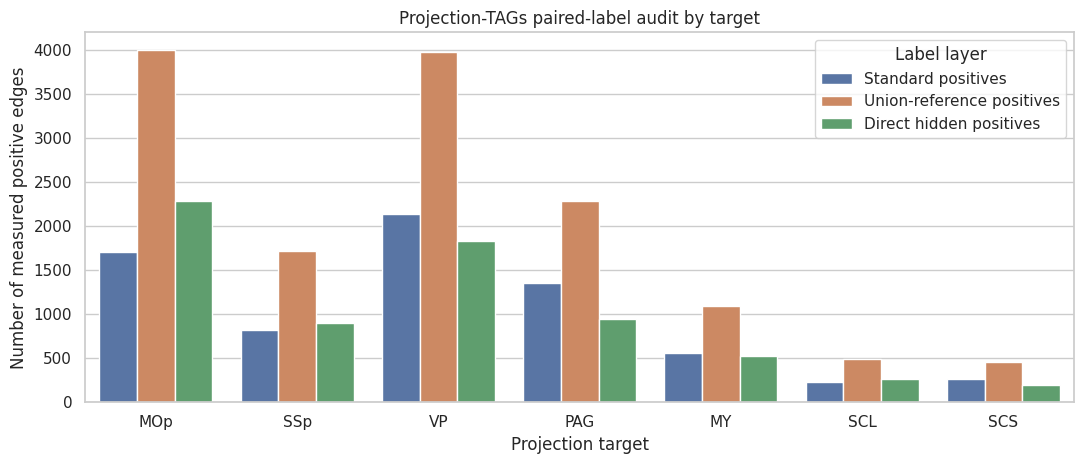

In [6]:
target_summary = pd.DataFrame({
    "Target": TARGETS,
    "Measured cells": W.sum(axis=0).astype(int),
    "Standard positives": np.nansum(S_standard, axis=0).astype(int),
    "Union-reference positives": np.nansum(U_union, axis=0).astype(int),
    "Direct hidden positives": H_direct.sum(axis=0).astype(int),
})
target_summary["Standard sensitivity vs union reference"] = (
    target_summary["Standard positives"]
    / target_summary["Union-reference positives"].clip(lower=1)
)
display(target_summary)

animal_summary = []
for animal in range(1, 7):
    rows = animal_id == animal
    animal_summary.append({
        "Animal": animal,
        "Treatment": ", ".join(sorted(set(treatment[rows]))),
        "Platforms": ", ".join(sorted(set(platform[rows]))),
        "Cells": int(rows.sum()),
        "Measured pairs": int(W[rows].sum()),
        "Standard positives": int(np.nansum(S_standard[rows])),
        "Union-reference positives": int(np.nansum(U_union[rows])),
        "Direct hidden positives": int(H_direct[rows].sum()),
    })
animal_summary = pd.DataFrame(animal_summary)
display(animal_summary)

plot_table = target_summary.melt(
    id_vars="Target",
    value_vars=["Standard positives", "Union-reference positives", "Direct hidden positives"],
    var_name="Label layer",
    value_name="Edges",
)
plt.figure(figsize=(11, 4.8))
sns.barplot(data=plot_table, x="Target", y="Edges", hue="Label layer")
plt.title("Projection-TAGs paired-label audit by target")
plt.ylabel("Number of measured positive edges")
plt.xlabel("Projection target")
plt.tight_layout()
plt.show()


## 5. Cheap diagnostic: is low-rank sharing plausible in standard labels?

This descriptive diagnostic uses only standard-assay labels and is not supplied to any model or tuner. The singular spectrum is restricted to cells for which all seven targets were injected (animals 5 and 6), so unmeasured SSp entries are never imputed as negatives.


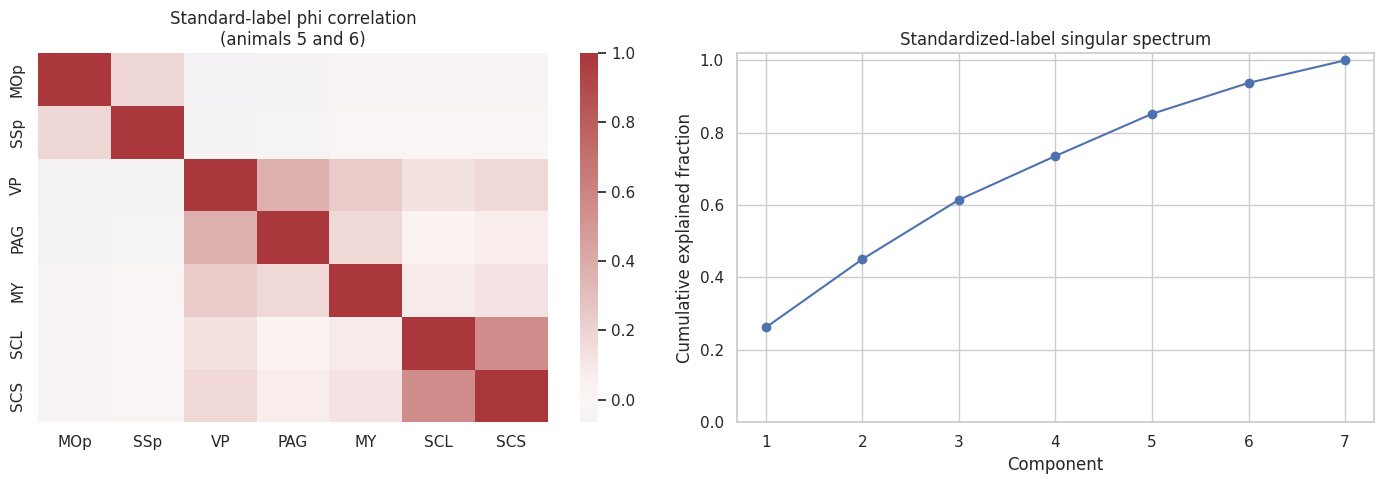

,Component,Explained fraction,Cumulative explained fraction
0,1,0.262099,0.262099
1,2,0.188642,0.450741
2,3,0.164155,0.614896
3,4,0.120961,0.735857
4,5,0.116345,0.852203
5,6,0.085573,0.937776
6,7,0.062224,1.000000


In [7]:
complete_target_rows = W.all(axis=1)
S_complete = S_standard[complete_target_rows].astype(float)
assert np.isfinite(S_complete).all()

target_prevalence = S_complete.mean(axis=0)
phi_matrix = np.corrcoef(S_complete, rowvar=False)
jaccard_matrix = np.zeros((len(TARGETS), len(TARGETS)), dtype=float)
for left in range(len(TARGETS)):
    for right in range(len(TARGETS)):
        intersection = np.sum((S_complete[:, left] > 0.5) & (S_complete[:, right] > 0.5))
        union = np.sum((S_complete[:, left] > 0.5) | (S_complete[:, right] > 0.5))
        jaccard_matrix[left, right] = intersection / max(union, 1)

scale = np.sqrt(np.maximum(target_prevalence * (1 - target_prevalence), 1e-8))
S_standardized = (S_complete - target_prevalence) / scale
singular_values = np.linalg.svd(S_standardized, full_matrices=False, compute_uv=False)
explained = singular_values**2 / np.sum(singular_values**2)
rank_diagnostic = pd.DataFrame({
    "Component": np.arange(1, len(explained) + 1),
    "Explained fraction": explained,
    "Cumulative explained fraction": np.cumsum(explained),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(phi_matrix, xticklabels=TARGETS, yticklabels=TARGETS,
            center=0, cmap="vlag", ax=axes[0])
axes[0].set_title("Standard-label phi correlation\n(animals 5 and 6)")
axes[1].plot(rank_diagnostic["Component"],
             rank_diagnostic["Cumulative explained fraction"], marker="o")
axes[1].set_xticks(rank_diagnostic["Component"])
axes[1].set_ylim(0, 1.02)
axes[1].set_title("Standardized-label singular spectrum")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Cumulative explained fraction")
plt.tight_layout()
plt.show()
display(rank_diagnostic)


# Animal-grouped split and fold-specific preprocessing


## 6. Three outer folds with one fixed validation animal


In [8]:
OUTER_TEST_ANIMALS = [(1, 4), (2, 6), (3, 5)]
# Restore the original design-variable-only validation choice.  Each three-animal
# model-training set retains both 10X platforms and measured SSp (animal 5 or 6).
INNER_VALIDATION_ANIMAL = {0: 2, 1: 4, 2: 1}

assert N_OUTER_FOLDS == len(OUTER_TEST_ANIMALS) == 3
assert set(animal for pair in OUTER_TEST_ANIMALS for animal in pair) == set(range(1, 7))
assert all(len(pair) == 2 for pair in OUTER_TEST_ANIMALS)
assert all(
    set(treatment[np.isin(animal_id, pair)]) == {"CYP", "Saline"}
    for pair in OUTER_TEST_ANIMALS
)


def outer_fold_masks(outer_fold):
    test_animals = set(OUTER_TEST_ANIMALS[outer_fold])
    validation_animals = {int(INNER_VALIDATION_ANIMAL[outer_fold])}
    remaining_animals = set(range(1, 7)) - test_animals
    assert validation_animals.issubset(remaining_animals)
    training_animals = remaining_animals - validation_animals

    train_mask = np.isin(animal_id, sorted(training_animals))
    val_mask = np.isin(animal_id, sorted(validation_animals))
    test_mask = np.isin(animal_id, sorted(test_animals))

    membership = train_mask.astype(int) + val_mask.astype(int) + test_mask.astype(int)
    assert np.all(membership == 1)
    assert training_animals.isdisjoint(validation_animals)
    assert training_animals.isdisjoint(test_animals)
    assert validation_animals.isdisjoint(test_animals)
    assert len(training_animals) == 3
    assert len(validation_animals) == 1
    assert len(test_animals) == 2
    assert len(training_animals & {5, 6}) >= 1
    assert set(platform[train_mask]) == {"10X RNA", "10X multiome"}
    assert W[train_mask, TARGETS.index("SSp")].any()

    return (
        train_mask,
        val_mask,
        test_mask,
        training_animals,
        validation_animals,
        test_animals,
    )


split_rows = []
test_visit_count = np.zeros(n_cells, dtype=int)
for outer_fold in range(N_OUTER_FOLDS):
    train_mask, val_mask, test_mask, train_animals, val_animals, test_animals = (
        outer_fold_masks(outer_fold)
    )
    test_visit_count += test_mask.astype(int)
    for role, mask, animals in [
        ("Model train", train_mask, train_animals),
        ("Inner validation", val_mask, val_animals),
        ("Outer test", test_mask, test_animals),
    ]:
        split_rows.append({
            "Outer fold": outer_fold + 1,
            "Role": role,
            "Animals": ", ".join(map(str, sorted(animals))),
            "Cells": int(mask.sum()),
            "Platforms": ", ".join(sorted(set(platform[mask]))),
            "Measured pairs": int(W[mask].sum()),
            "Standard prevalence": float(np.nanmean(S_standard[mask])),
        })

assert np.all(test_visit_count == 1)
assert [
    tuple(sorted(outer_fold_masks(fold)[3])) for fold in range(N_OUTER_FOLDS)
] == [(3, 5, 6), (1, 3, 5), (2, 4, 6)]
assert [
    int(next(iter(outer_fold_masks(fold)[4]))) for fold in range(N_OUTER_FOLDS)
] == [2, 4, 1]
cv_split_summary = pd.DataFrame(split_rows)
display(cv_split_summary)
print("Every modeled cell appears in an outer-test set exactly once.")
print("Each outer fold uses three model-train, one fixed validation, and two test animals.")
print("SSp is absent from fixed validation scores but remains in training and measured OOF tests.")


,Outer fold,Role,Animals,Cells,Platforms,Measured pairs,Standard prevalence
0,1,Model train,"3, 5, 6",22408,"10X RNA, 10X multiome",153311,0.041673
1,1,Inner validation,2,4166,10X multiome,24996,0.000480
2,1,Outer test,"1, 4",11253,"10X RNA, 10X multiome",67518,0.009938
3,2,Model train,"1, 3, 5",19155,"10X RNA, 10X multiome",123846,0.033493
4,2,Inner validation,4,4559,10X RNA,27354,0.022849
5,2,Outer test,"2, 6",14113,10X multiome,94625,0.024296
6,3,Model train,"2, 4, 6",18672,"10X RNA, 10X multiome",121979,0.023971
7,3,Inner validation,1,6694,10X multiome,40164,0.001145
8,3,Outer test,"3, 5",12461,"10X RNA, 10X multiome",83682,0.049019


Every modeled cell appears in an outer-test set exactly once.
Each outer fold uses three model-train, one fixed validation, and two test animals.
SSp is absent from fixed validation scores but remains in training and measured OOF tests.


## 7. Fold-specific preprocessing

Each scaler is fitted only on the three model-training animals, then frozen for its validation animal and two outer-test animals.


In [9]:
def prepare_fold_features(train_mask):
    normalized_gene = (
        10_000.0 * X_gene_raw / np.maximum(library_size_raw[:, None], 1.0)
    )
    gene_log = np.log1p(np.clip(normalized_gene, 0, None))
    gene_scaler = StandardScaler().fit(gene_log[train_mask])
    X_gene_fold = gene_scaler.transform(gene_log).astype(np.float32)

    origin_scaler = StandardScaler().fit(X_loc_raw[train_mask])
    X_origin_fold = origin_scaler.transform(X_loc_raw).astype(np.float32)

    X_fold = np.concatenate([X_gene_fold, X_origin_fold], axis=1).astype(np.float32)
    assert X_fold.shape[1] == len(FEATURE_NAMES) == 33
    assert np.isfinite(X_fold).all()
    assert set(FEATURE_NAMES).isdisjoint(FORBIDDEN_FEATURE_NAMES)
    return X_fold


example_train_mask = outer_fold_masks(0)[0]
example_X = prepare_fold_features(example_train_mask)
print("Gene + source-origin feature shape:", example_X.shape)
print("Features:", len(GENE_FEATURES), "endogenous genes + 1 origin feature")
print("Target/Y features used in X: 0")
del example_X, example_train_mask


Gene + source-origin feature shape: (37827, 33)
Features: 32 endogenous genes + 1 origin feature
Target/Y features used in X: 0


# One shared model boundary for every dataset

This notebook passes only processed, reference-free `DatasetBundle` objects, exposure matrices, the generic hyperparameter grid, and unlabeled `test_X` to `gene2wire.run_model_grid`. SPIDER and Projection-TAGs therefore use the same `UnifiedPUModel`, likelihood, regularization convention, initialization code, optimizer, tuning code, prediction API, fingerprinting, and checkpoint implementation from `main`.

`U_union`, hidden-positive masks, raw-file formats, target names, animal identities, calibration construction, and scientific evaluation remain notebook-only. Outer-test labels never cross the model boundary.


In [10]:
from gene2wire import (
    DatasetBundle,
    FitConfig,
    ModelConfig,
    TuningConfig,
    UnifiedPUModel,
    run_model_grid,
)
from gene2wire.tuning import full_joint_candidates

core_signature = inspect.signature(run_model_grid)
assert "test_X" in core_signature.parameters
assert "test_labels" not in core_signature.parameters
assert "reference" not in core_signature.parameters
assert UnifiedPUModel.__module__ == "gene2wire.models"
print("Unified model boundary verified: run_model_grid + UnifiedPUModel from main.")


Unified model boundary verified: run_model_grid + UnifiedPUModel from main.


## 8. Metrics and real paired sensitivity calibration

The notebook keeps three quantities distinct:

| Scientific question | Prediction | Outer-test evaluator |
|---|---|---|
| Higher-sensitivity reference ranking/calibration | latent $\hat p$ | measured union $U$ |
| Standard-assay fit | detection $\hat q$ | measured standard label $S$ |
| Direct hidden-positive retrieval | $\hat p$ or PU false-negative posterior | $U=1$ among measured $S=0$ candidates |

`Union-reference` is used in every probability-metric name to avoid calling the amplified union complete biological truth. `Amplification-discovery AUPRC` is a direct paired-label endpoint, replacing the old semisynthetic `Proxy AUPRC` name. Recall@H uses the retrospective number of hidden positives in the test pool and is an evaluation statistic, not a deployable cutoff.


In [11]:
def binary_log_loss(labels, probabilities):
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-6, 1 - 1e-6)
    labels = np.asarray(labels, dtype=float)
    return float(-np.mean(
        labels * np.log(probabilities)
        + (1 - labels) * np.log1p(-probabilities)
    ))


CORE_MODEL_NAMES = [
    "Logistic", "PU logistic",
    "MIRT", "PU-MIRT",
    "Joint", "PU-Joint",
]
MODEL_FACTORS = {
    "Logistic": {"Structure": "direct", "Coefficient structure": "Independent", "PU": False},
    "PU logistic": {"Structure": "direct", "Coefficient structure": "Independent", "PU": True},
    "MIRT": {"Structure": "lowrank", "Coefficient structure": "Low rank", "PU": False},
    "PU-MIRT": {"Structure": "lowrank", "Coefficient structure": "Low rank", "PU": True},
    "Joint": {"Structure": "joint", "Coefficient structure": "Low rank + dense ridge residual", "PU": False},
    "PU-Joint": {"Structure": "joint", "Coefficient structure": "Low rank + dense ridge residual", "PU": True},
}


def recall_at_k(labels, scores, k=100):
    labels = np.asarray(labels, dtype=float)
    scores = np.asarray(scores, dtype=float)
    positives = float(labels.sum())
    if positives <= 0:
        return np.nan
    k = min(int(k), len(labels))
    top = np.argsort(-scores, kind="mergesort")[:k]
    return float(labels[top].sum() / positives)


def tie_aware_recall_at_h(labels, scores, h):
    labels = np.asarray(labels, dtype=float)
    scores = np.asarray(scores, dtype=float)
    h = min(int(h), len(labels))
    if h <= 0 or labels.sum() == 0:
        return np.nan
    threshold = np.sort(scores)[-h]
    above = scores > threshold
    tied = scores == threshold
    remaining = h - int(above.sum())
    expected_hits = labels[above].sum()
    if remaining > 0 and tied.sum() > 0:
        expected_hits += (remaining / tied.sum()) * labels[tied].sum()
    return float(expected_hits / labels.sum())


def equal_frequency_calibration(labels, probabilities, n_bins=N_CALIBRATION_BINS):
    labels = np.asarray(labels, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    order = np.argsort(probabilities, kind="mergesort")
    bins = []
    for bin_index, indices in enumerate(np.array_split(order, min(n_bins, len(order)))):
        if len(indices) == 0:
            continue
        bins.append({
            "Calibration bin": bin_index + 1,
            "Bin count": int(len(indices)),
            "Mean predicted probability": float(np.mean(probabilities[indices])),
            "Observed frequency": float(np.mean(labels[indices])),
        })
    return bins


def expected_calibration_error(labels, probabilities, n_bins=N_CALIBRATION_BINS):
    bins = equal_frequency_calibration(labels, probabilities, n_bins)
    total = max(sum(row["Bin count"] for row in bins), 1)
    return float(sum(
        row["Bin count"] / total
        * abs(row["Mean predicted probability"] - row["Observed frequency"])
        for row in bins
    ))


def evaluate_discrimination_per_target(union_labels, measured_mask, scores):
    rows = []
    for target_index, target in enumerate(TARGETS):
        measured = measured_mask[:, target_index]
        y = union_labels[measured, target_index].astype(float)
        p = scores[measured, target_index].astype(float)
        if np.unique(y).size < 2:
            continue
        rows.append({
            "Target": target,
            "Union-reference AUPRC": float(average_precision_score(y, p)),
            "Union-reference AUROC": float(roc_auc_score(y, p)),
            "Union-reference Recall@100": recall_at_k(y, p, 100),
        })
    return rows


def evaluate_probability_metrics_per_target(
    union_labels,
    standard_labels,
    measured_mask,
    latent_probability,
    detection_probability,
):
    metric_rows = []
    calibration_rows = []
    for target_index, target in enumerate(TARGETS):
        measured = measured_mask[:, target_index]
        if not np.any(measured):
            continue
        union_y = union_labels[measured, target_index].astype(float)
        standard_y = standard_labels[measured, target_index].astype(float)
        latent_p = np.clip(latent_probability[measured, target_index], 1e-6, 1 - 1e-6)
        detection_q = np.clip(detection_probability[measured, target_index], 1e-6, 1 - 1e-6)
        union_prevalence = float(np.mean(union_y))
        predicted_prevalence = float(np.mean(latent_p))

        metric_rows.append({
            "Target": target,
            "Union-reference Brier": float(np.mean((latent_p - union_y) ** 2)),
            "Union-reference log loss": binary_log_loss(union_y, latent_p),
            "Union-reference ECE": expected_calibration_error(union_y, latent_p),
            "Union-reference prevalence": union_prevalence,
            "Predicted reference prevalence": predicted_prevalence,
            "Reference prevalence bias": predicted_prevalence - union_prevalence,
            "Reference prevalence absolute error": abs(predicted_prevalence - union_prevalence),
            "Reference prevalence ratio": predicted_prevalence / max(union_prevalence, 1e-12),
            "Standard-assay Brier": float(np.mean((detection_q - standard_y) ** 2)),
            "Standard-assay log loss": binary_log_loss(standard_y, detection_q),
            "Standard-assay ECE": expected_calibration_error(standard_y, detection_q),
        })
        for row in equal_frequency_calibration(union_y, latent_p):
            calibration_rows.append({"Target": target, "Probability": "Union-reference p", **row})
        for row in equal_frequency_calibration(standard_y, detection_q):
            calibration_rows.append({"Target": target, "Probability": "Standard-assay q", **row})
    return metric_rows, calibration_rows


def make_paired_calibration_mask(animal_values, seed):
    """Label-independent, approximately 20% within every model-train animal."""
    rng = np.random.default_rng(int(seed))
    animal_values = np.asarray(animal_values, dtype=int)
    mask = np.zeros(len(animal_values), dtype=bool)
    for animal in np.unique(animal_values):
        indices = np.flatnonzero(animal_values == animal)
        chosen_count = max(1, int(round(PAIRED_CALIBRATION_FRACTION * len(indices))))
        mask[rng.choice(indices, size=chosen_count, replace=False)] = True
    return mask


def _smoothed_detection_rate(standard_positive_count, union_positive_count):
    if union_positive_count <= 0:
        return np.nan
    return float((standard_positive_count + 0.5) / (union_positive_count + 1.0))


def estimate_sensitivity_from_paired_calibration(
    platform_train,
    platform_all,
    S_train,
    U_train,
    W_train,
    calibration_mask,
):
    """Estimate platform × target P(S=1 | U=1) with train-only fallbacks."""
    platform_train = np.asarray(platform_train).astype(str)
    platform_all = np.asarray(platform_all).astype(str)
    calibration_mask = np.asarray(calibration_mask, dtype=bool)
    paired_union = calibration_mask[:, None] & W_train & (U_train > 0.5)
    paired_standard = paired_union & (S_train > 0.5)

    global_union_count = int(paired_union.sum())
    global_standard_count = int(paired_standard.sum())
    global_rate = _smoothed_detection_rate(global_standard_count, global_union_count)
    assert np.isfinite(global_rate)

    target_rates = np.full(n_targets, np.nan, dtype=float)
    for target_index in range(n_targets):
        union_count = int(paired_union[:, target_index].sum())
        standard_count = int(paired_standard[:, target_index].sum())
        target_rates[target_index] = (
            _smoothed_detection_rate(standard_count, union_count)
            if union_count > 0 else global_rate
        )

    sensitivity_all = np.ones((len(platform_all), n_targets), dtype=np.float32)
    audit_rows = []
    observed_training_platforms = set(platform_train)
    for platform_name in sorted(np.unique(platform_all)):
        platform_observed_in_training = platform_name in observed_training_platforms
        train_group = platform_train == platform_name
        all_group = platform_all == platform_name
        for target_index, target in enumerate(TARGETS):
            eligible = train_group & paired_union[:, target_index]
            union_count = int(eligible.sum())
            standard_count = int((eligible & (S_train[:, target_index] > 0.5)).sum())
            if (
                platform_observed_in_training
                and union_count >= MIN_PLATFORM_TARGET_CALIBRATION_POSITIVES
            ):
                rate = _smoothed_detection_rate(standard_count, union_count)
                source = "platform × target"
            elif np.isfinite(target_rates[target_index]):
                rate = float(target_rates[target_index])
                source = (
                    "target-pooled fallback"
                    if platform_observed_in_training
                    else "unseen-platform target-pooled fallback"
                )
            else:
                rate = float(global_rate)
                source = (
                    "global fallback"
                    if platform_observed_in_training
                    else "unseen-platform global fallback"
                )
            rate = float(np.clip(rate, EPSILON + 1e-4, 1.0))
            sensitivity_all[all_group, target_index] = rate
            audit_rows.append({
                "Platform": platform_name,
                "Target": target,
                "Paired union positives": union_count,
                "Paired standard positives": standard_count,
                "Estimated sensitivity": rate,
                "Estimate source": source,
            })

    return sensitivity_all, pd.DataFrame(audit_rows)


def false_negative_posterior(latent_probability, sensitivity, epsilon=EPSILON):
    latent_probability = np.clip(np.asarray(latent_probability, dtype=float), 1e-6, 1 - 1e-6)
    sensitivity = np.clip(np.asarray(sensitivity, dtype=float), epsilon + 1e-6, 1.0)
    detection_probability = epsilon + (sensitivity - epsilon) * latent_probability
    numerator = (1 - sensitivity) * latent_probability
    denominator = np.maximum(1 - detection_probability, 1e-8)
    return np.clip(numerator / denominator, 0.0, 1.0)


def recovery_metrics_per_target(standard_labels, union_labels, measured_mask, scores, score_type):
    rows = []
    scores = np.asarray(scores, dtype=float)
    for target_index, target in enumerate(TARGETS):
        candidates = measured_mask[:, target_index] & (standard_labels[:, target_index] < 0.5)
        candidate_scores = scores[candidates, target_index]
        candidate_labels = (union_labels[candidates, target_index] > 0.5).astype(int)
        hidden_count = int(candidate_labels.sum())
        if hidden_count == 0 or len(candidate_labels) <= hidden_count:
            continue
        recall_h = tie_aware_recall_at_h(candidate_labels, candidate_scores, hidden_count)
        random_recall = hidden_count / len(candidate_labels)
        percentiles = (
            rankdata(candidate_scores, method="average") - 1
        ) / max(len(candidate_scores) - 1, 1)
        rows.append({
            "Target": target,
            "Score type": score_type,
            "Candidate standard-zero pairs": int(len(candidate_labels)),
            "Direct hidden positives": hidden_count,
            "Amplification-discovery AUPRC": float(
                average_precision_score(candidate_labels, candidate_scores)
            ),
            "Hidden Recall@H": recall_h,
            "Recovered hidden positives at H": float(recall_h * hidden_count),
            "Random Recall@H": float(random_recall),
            "Enrichment over random": float(recall_h / random_recall),
            "Mean hidden percentile": float(np.mean(percentiles[candidate_labels == 1])),
        })
    return rows


## 9. Declare the model families and generic grid

These are the same six coefficient structures and the same `ModelConfig`, `TuningConfig`, and `FitConfig` interfaces used by the SPIDER notebook. The rank values are bounded by Projection-TAGs' seven targets; everything else is handled by the common core. No dataset-specific model subclass or optimizer is defined here.


In [12]:
CORE_MODEL_NAMES = [
    "Logistic", "PU logistic",
    "MIRT", "PU-MIRT",
    "Joint", "PU-Joint",
]
MODEL_FACTORS = {
    "Logistic": {"Structure": "direct", "Coefficient structure": "Independent", "PU": False},
    "PU logistic": {"Structure": "direct", "Coefficient structure": "Independent", "PU": True},
    "MIRT": {"Structure": "lowrank", "Coefficient structure": "Low rank", "PU": False},
    "PU-MIRT": {"Structure": "lowrank", "Coefficient structure": "Low rank", "PU": True},
    "Joint": {"Structure": "joint", "Coefficient structure": "Low rank + dense residual", "PU": False},
    "PU-Joint": {"Structure": "joint", "Coefficient structure": "Low rank + dense residual", "PU": True},
}

CORE_MODELS = tuple(
    ModelConfig(
        name=model_name,
        kind=MODEL_FACTORS[model_name]["Structure"],
        rank=(0 if MODEL_FACTORS[model_name]["Structure"] == "direct" else 4),
        pu=bool(MODEL_FACTORS[model_name]["PU"]),
    )
    for model_name in CORE_MODEL_NAMES
)
CORE_TUNING = TuningConfig(
    strategy="full_joint",
    ranks=(0, 1, 2, 4, 6),
    shared_l2=(1e-5, 1e-3, 1e-2),
    residual_l2=(1e-5, 1e-3, 1e-2),
    target_l2=(1e-3,),
    anchor_shared_l2=1e-3,
    anchor_residual_l2=1e-3,
    anchor_target_l2=1e-3,
    metric="observed_log_loss",
)
CORE_FIT = FitConfig(
    maxiter=CORE_MAXITER,
    tolerance=1e-8,
    initialization="svd",
    init_direct_maxiter=CORE_INIT_DIRECT_MAXITER,
)

GRID_EXPECTATIONS = {
    model.name: len(full_joint_candidates(model, CORE_TUNING))
    for model in CORE_MODELS
}
grid_table = pd.DataFrame([
    {**asdict(model), "candidate_count": GRID_EXPECTATIONS[model.name]}
    for model in CORE_MODELS
])
display(grid_table)
print("Core model class:", UnifiedPUModel.__module__ + "." + UnifiedPUModel.__name__)
print("Core runner:", run_model_grid.__module__ + "." + run_model_grid.__name__)
print("Candidates per outer fold:", sum(GRID_EXPECTATIONS.values()))


,name,kind,rank,shared_l2,residual_l2,use_target_features,target_l2,pu,candidate_count
0,Logistic,direct,0,0.0,0.0,False,0.0,False,3
1,PU logistic,direct,0,0.0,0.0,False,0.0,True,3
2,MIRT,lowrank,4,0.0,0.0,False,0.0,False,12
3,PU-MIRT,lowrank,4,0.0,0.0,False,0.0,True,12
4,Joint,joint,4,0.0,0.0,False,0.0,False,39
5,PU-Joint,joint,4,0.0,0.0,False,0.0,True,39


Core model class: gene2wire.models.UnifiedPUModel
Core runner: gene2wire.runner.run_model_grid
Candidates per outer fold: 108


# Experiment — notebook split/calibration, one common core, notebook evaluation

For each outer fold, the notebook fits preprocessing and paired sensitivity using the three model-training animals, creates reference-free core bundles, and calls the same `run_model_grid` used by SPIDER. The fixed validation animal is used for hyperparameter selection. A custom refit bundle masks all validation outcomes, so the final objective still uses only the original three training animals while remaining inside the standard generic core API.

All six outer-test prediction matrices are returned before this notebook reads `U_union` or any hidden-positive evaluation label.


In [13]:
def build_single_validation_fold_data(outer_fold, fold_seed):
    (
        train_mask,
        val_mask,
        test_mask,
        training_animals,
        validation_animals,
        test_animals,
    ) = outer_fold_masks(outer_fold)

    X_all = prepare_fold_features(train_mask)
    S_train = S_standard[train_mask]
    S_val = S_standard[val_mask]
    W_train = W[train_mask]
    W_val = W[val_mask]
    calibration_mask = make_paired_calibration_mask(
        animal_id[train_mask], fold_seed + 205_001
    )
    sensitivity_all, sensitivity_audit = estimate_sensitivity_from_paired_calibration(
        platform[train_mask], platform, S_train, U_union[train_mask],
        W_train, calibration_mask,
    )
    eligible_targets = W_train.any(axis=0) & W_val.any(axis=0)
    if not eligible_targets.any():
        raise RuntimeError("The fixed validation split has no eligible target.")
    W_val_score = W_val.copy()
    W_val_score[:, ~eligible_targets] = False
    excluded = [target for target, keep in zip(TARGETS, eligible_targets) if not keep]

    sensitivity_audit.insert(0, "Outer fold", outer_fold + 1)
    sensitivity_audit.insert(1, "Calibration level", "Single fixed validation")
    sensitivity_audit.insert(2, "Selection split", 1)
    sensitivity_audit.insert(3, "Inner-validation animal", int(next(iter(validation_animals))))
    sensitivity_audit.insert(4, "Model-train animals", ", ".join(map(str, sorted(training_animals))))
    sensitivity_audit.insert(5, "Paired calibration cells", int(calibration_mask.sum()))
    sensitivity_audit.insert(6, "Targets excluded from validation score", ", ".join(excluded) if excluded else "None")

    feature_blocks = {
        "endogenous_genes": tuple(range(len(GENE_FEATURES))),
        "source_origin": (len(GENE_FEATURES),),
    }
    shared = {
        "target_ids": TARGETS,
        "feature_blocks": feature_blocks,
        "semantics": {"label": "observed positive; zero is unlabeled"},
    }
    train_bundle = DatasetBundle(
        X_cell=X_all[train_mask],
        S_observed=np.where(W_train, S_train, 0).astype(np.uint8),
        W_measured=W_train,
        cell_ids=cell_ids[train_mask],
        groups={"group": animal_id[train_mask], "platform": platform[train_mask]},
        **shared,
    )
    validation_bundle = DatasetBundle(
        X_cell=X_all[val_mask],
        S_observed=np.where(W_val_score, S_val, 0).astype(np.uint8),
        W_measured=W_val_score,
        cell_ids=cell_ids[val_mask],
        groups={"group": animal_id[val_mask], "platform": platform[val_mask]},
        **shared,
    )

    # run_model_grid requires refit IDs to equal the train/validation union.
    # Validation W is set to zero, so its labels cannot enter the final loss.
    refit_bundle = DatasetBundle(
        X_cell=np.concatenate([X_all[train_mask], X_all[val_mask]], axis=0),
        S_observed=np.concatenate([
            np.where(W_train, S_train, 0).astype(np.uint8),
            np.zeros_like(W_val_score, dtype=np.uint8),
        ], axis=0),
        W_measured=np.concatenate([
            W_train,
            np.zeros_like(W_val_score, dtype=bool),
        ], axis=0),
        cell_ids=np.concatenate([cell_ids[train_mask], cell_ids[val_mask]]),
        groups={
            "group": np.concatenate([animal_id[train_mask], animal_id[val_mask]]),
            "platform": np.concatenate([platform[train_mask], platform[val_mask]]),
        },
        **shared,
    )

    assert len(training_animals) == 3
    assert len(validation_animals) == 1
    assert len(test_animals) == 2
    assert W_train[:, TARGETS.index("SSp")].any()
    assert not eligible_targets[TARGETS.index("SSp")]
    assert train_bundle.Z_reference is None
    assert validation_bundle.Z_reference is None
    assert refit_bundle.Z_reference is None
    assert not refit_bundle.W_measured[train_bundle.n_cells:].any()
    return {
        "train": train_bundle,
        "validation": validation_bundle,
        "refit": refit_bundle,
        "X_test": X_all[test_mask],
        "test_cell_ids": cell_ids[test_mask],
        "test_mask": test_mask,
        "training_animals": training_animals,
        "validation_animals": validation_animals,
        "test_animals": test_animals,
        "sensitivity_train": sensitivity_all[train_mask],
        "sensitivity_validation": sensitivity_all[val_mask],
        "sensitivity_refit": np.concatenate([
            sensitivity_all[train_mask], sensitivity_all[val_mask]
        ], axis=0),
        "sensitivity_test": sensitivity_all[test_mask],
        "eligible_targets": eligible_targets,
        "sensitivity_audit": sensitivity_audit,
    }


def report_model(model_name, status):
    print(f"    {model_name:11s}: {status}")


STRUCTURE_DISPLAY = {"direct": "direct", "lowrank": "low_rank", "joint": "joint"}
selected_rows = []
calibration_audit_frames = []
tuning_frames = []
budget_selection_frames = []
fold_result_rows = []
fold_fingerprints = []
core_contract_rows = []
core_class_rows = []

oof_latent = {name: np.full((n_cells, n_targets), np.nan, np.float32) for name in CORE_MODEL_NAMES}
oof_detection = {name: np.full((n_cells, n_targets), np.nan, np.float32) for name in CORE_MODEL_NAMES}
oof_recovery_score = {name: np.full((n_cells, n_targets), np.nan, np.float32) for name in CORE_MODEL_NAMES}
oof_sensitivity = np.full((n_cells, n_targets), np.nan, np.float32)
oof_visit_count = np.zeros(n_cells, dtype=int)

for outer_fold in range(N_OUTER_FOLDS):
    fold_start = time.time()
    fold_seed = RANDOM_SEED + outer_fold
    fold_data = build_single_validation_fold_data(outer_fold, fold_seed)
    test_mask = fold_data["test_mask"]
    training_animals = fold_data["training_animals"]
    validation_animals = fold_data["validation_animals"]
    test_animals = fold_data["test_animals"]
    calibration_audit_frames.append(fold_data["sensitivity_audit"])
    oof_visit_count += test_mask.astype(int)
    oof_sensitivity[test_mask] = fold_data["sensitivity_test"]

    print(
        f"Fold {outer_fold + 1}/{N_OUTER_FOLDS}; train={sorted(training_animals)}, "
        f"validation={sorted(validation_animals)}, test={sorted(test_animals)}"
    )
    core_result = run_model_grid(
        train=fold_data["train"],
        validation=fold_data["validation"],
        refit=fold_data["refit"],
        test_X=fold_data["X_test"],
        test_cell_ids=fold_data["test_cell_ids"],
        train_exposure=fold_data["sensitivity_train"],
        validation_exposure=fold_data["sensitivity_validation"],
        refit_exposure=fold_data["sensitivity_refit"],
        test_exposure=fold_data["sensitivity_test"],
        models=CORE_MODELS,
        tuning=CORE_TUNING,
        fit=CORE_FIT,
        checkpoint_dir=CHECKPOINT_DIR / f"fold_{outer_fold + 1:02d}",
        unit_context={
            "outer_fold": outer_fold + 1,
            "run_mode": RUN_MODE,
            "validation_design": "single_fixed_group",
        },
        seed=fold_seed,
        code_version=MAIN_COMMIT,
        on_model=report_model,
    )
    fold_fingerprints.append(core_result.fingerprint)
    core_contract_rows.append({
        "Outer fold": outer_fold + 1,
        "Core ref": CORE_REF,
        "Resolved main commit": MAIN_COMMIT,
        "Train reference absent": fold_data["train"].Z_reference is None,
        "Validation reference absent": fold_data["validation"].Z_reference is None,
        "Refit reference absent": fold_data["refit"].Z_reference is None,
        "Test labels passed to core": False,
        "Validation measured entries in final refit": int(
            fold_data["refit"].W_measured[fold_data["train"].n_cells:].sum()
        ),
        "Core fingerprint": core_result.fingerprint,
    })

    # Store all predictions before reading outer-test reference labels.
    for model_name in CORE_MODEL_NAMES:
        model_result = core_result.models[model_name]
        uses_pu = bool(model_result.tuning.best_config.pu)
        sensitivity_for_model = fold_data["sensitivity_test"] if uses_pu else np.ones_like(fold_data["sensitivity_test"])
        latent = model_result.latent_probability
        detection = model_result.observed_probability
        recovery = false_negative_posterior(latent, sensitivity_for_model) if uses_pu else latent
        oof_latent[model_name][test_mask] = latent
        oof_detection[model_name][test_mask] = detection
        oof_recovery_score[model_name][test_mask] = recovery
        core_class_rows.append({
            "Outer fold": outer_fold + 1,
            "Model": model_name,
            "Fitted class": type(model_result.fitted).__name__,
            "Fitted module": type(model_result.fitted).__module__,
        })

        config = model_result.tuning.best_config
        selected_rows.append({
            "Outer fold": outer_fold + 1,
            "Model-train animals": ", ".join(map(str, sorted(training_animals))),
            "Inner-validation animal": int(next(iter(validation_animals))),
            "Inner-validation design": "one fixed animal",
            "Outer-test animals": ", ".join(map(str, sorted(test_animals))),
            "Model": model_name,
            "PU": uses_pu,
            "Sensitivity source": "Model-train paired calibration" if uses_pu else "Fixed at one",
            "Mean model sensitivity train": float(np.mean(
                (fold_data["sensitivity_train"] if uses_pu else np.ones_like(fold_data["sensitivity_train"]))
                [fold_data["train"].W_measured]
            )),
            "structure": STRUCTURE_DISPLAY[config.kind],
            "rank": int(config.rank),
            "shared_l2": float(config.shared_l2),
            "residual_l2": float(config.residual_l2),
            "target_l2": float(config.target_l2),
            "Validation detection log loss": float(model_result.tuning.best_validation_loss),
            "Final converged": bool(model_result.fitted.converged),
            "Final iterations": int(model_result.fitted.iterations),
            "Final objective": float(model_result.fitted.objective),
            "Core model resumed": bool(model_result.resumed),
        })

        trial_rows = []
        for trial in model_result.tuning.trials:
            candidate = trial.config
            trial_rows.append({
                "Outer fold": outer_fold + 1,
                "Model": model_name,
                "Candidate id": int(trial.index),
                "Tuning stage": trial.stage,
                "Inner fold": 1,
                "Inner-train animals": ", ".join(map(str, sorted(training_animals))),
                "Inner-validation animal": int(next(iter(validation_animals))),
                "Eligible targets": ", ".join(
                    target for target, keep in zip(TARGETS, fold_data["eligible_targets"]) if keep
                ),
                "structure": STRUCTURE_DISPLAY[candidate.kind],
                "rank": int(candidate.rank),
                "shared_l2": float(candidate.shared_l2),
                "residual_l2": float(candidate.residual_l2),
                "target_l2": float(candidate.target_l2),
                "Validation detection log loss": float(trial.validation_loss),
                "Converged": bool(trial.converged),
                "Iterations": int(trial.iterations),
                "Seed": int(trial.seed),
                "Candidate restored with completed model": bool(model_result.resumed),
            })
        tuning_frames.append(pd.DataFrame(trial_rows))
        budget_selection_frames.append(pd.DataFrame([{
            "Outer fold": outer_fold + 1,
            "Model": model_name,
            "Reported tuning budget": len(model_result.tuning.trials),
            "Selected tuning stage": next(
                trial.stage for trial in model_result.tuning.trials
                if trial.config == model_result.tuning.best_config
            ),
            "structure": STRUCTURE_DISPLAY[config.kind],
            "rank": int(config.rank),
            "shared_l2": float(config.shared_l2),
            "residual_l2": float(config.residual_l2),
            "Validation detection log loss": float(model_result.tuning.best_validation_loss),
        }]))

    # Evaluation-only outer-test arrays are first read here.
    U_test = U_union[test_mask]
    S_test = S_standard[test_mask]
    W_test = W[test_mask]
    for model_name in CORE_MODEL_NAMES:
        discrimination_part = pd.DataFrame(
            evaluate_discrimination_per_target(U_test, W_test, oof_latent[model_name][test_mask])
        )
        probability_part, _ = evaluate_probability_metrics_per_target(
            U_test, S_test, W_test,
            oof_latent[model_name][test_mask],
            oof_detection[model_name][test_mask],
        )
        recovery_part = pd.DataFrame(recovery_metrics_per_target(
            S_test, U_test, W_test, oof_recovery_score[model_name][test_mask],
            score_type="Model-specific recovery score",
        ))
        fold_row = {"Outer fold": outer_fold + 1, "Model": model_name}
        for frame in (discrimination_part, pd.DataFrame(probability_part), recovery_part):
            if not frame.empty:
                for column in frame.select_dtypes(include=[np.number]).columns:
                    fold_row[column] = float(frame[column].mean())
        fold_result_rows.append(fold_row)
    print(f"Fold minutes: {(time.time() - fold_start) / 60:.1f}\n")

assert np.all(oof_visit_count == 1)
assert np.isfinite(oof_sensitivity).all()
for model_name in CORE_MODEL_NAMES:
    assert np.isfinite(oof_latent[model_name]).all()
    assert np.isfinite(oof_detection[model_name]).all()
    assert np.isfinite(oof_recovery_score[model_name]).all()

selected_hyperparameters = pd.DataFrame(selected_rows)
calibration_sensitivity_audit = pd.concat(calibration_audit_frames, ignore_index=True)
tuning_log = pd.concat(tuning_frames, ignore_index=True, sort=False)
tuning_budget_selection_audit = pd.concat(budget_selection_frames, ignore_index=True, sort=False)
fold_results = pd.DataFrame(fold_result_rows)
core_contract_audit = pd.DataFrame(core_contract_rows)
core_model_class_audit = pd.DataFrame(core_class_rows)

discrimination_rows = []
probability_rows = []
calibration_rows = []
recovery_rows = []
for model_name in CORE_MODEL_NAMES:
    discrimination_rows.extend(
        {"Model": model_name, **row}
        for row in evaluate_discrimination_per_target(U_union, W, oof_latent[model_name])
    )
    metric_part, calibration_part = evaluate_probability_metrics_per_target(
        U_union, S_standard, W, oof_latent[model_name], oof_detection[model_name]
    )
    probability_rows.extend({"Model": model_name, **row} for row in metric_part)
    calibration_rows.extend({"Model": model_name, **row} for row in calibration_part)
    for score_type, score_matrix in (
        ("Common latent probability", oof_latent[model_name]),
        ("Model-specific recovery score", oof_recovery_score[model_name]),
    ):
        recovery_rows.extend(
            {"Model": model_name, **row}
            for row in recovery_metrics_per_target(
                S_standard, U_union, W, score_matrix, score_type
            )
        )

discrimination_per_target = pd.DataFrame(discrimination_rows)
probability_metrics_per_target = pd.DataFrame(probability_rows)
calibration_bins = pd.DataFrame(calibration_rows)
hidden_recovery_per_target = pd.DataFrame(recovery_rows)
assert len(selected_hyperparameters) == N_OUTER_FOLDS * len(CORE_MODEL_NAMES)
print("Completed", len(selected_hyperparameters), "unified-core model units.")


Fold 1/3; train=[3, 5, 6], validation=[2], test=[1, 4]
    Logistic   : started
    Logistic   : completed
    PU logistic: started
    PU logistic: completed
    MIRT       : started
    MIRT       : completed
    PU-MIRT    : started
    PU-MIRT    : completed
    Joint      : started
    Joint      : completed
    PU-Joint   : started
    PU-Joint   : completed
Fold minutes: 13.3

Fold 2/3; train=[1, 3, 5], validation=[4], test=[2, 6]
    Logistic   : started
    Logistic   : completed
    PU logistic: started
    PU logistic: completed
    MIRT       : started
    MIRT       : completed
    PU-MIRT    : started
    PU-MIRT    : completed
    Joint      : started
    Joint      : completed
    PU-Joint   : started
    PU-Joint   : completed
Fold minutes: 13.1

Fold 3/3; train=[2, 4, 6], validation=[1], test=[3, 5]
    Logistic   : started
    Logistic   : completed
    PU logistic: started
    PU logistic: completed
    MIRT       : started
    MIRT       : completed
    PU-MIRT    

## 10. Pooled out-of-fold results

Every modeled cell is predicted exactly once. Per-target metrics are computed from pooled OOF predictions and then macro-averaged across targets. Fold tables remain secondary diagnostics rather than independent biological replicates.

For PU models, hidden recovery uses the false-negative posterior; non-PU models use latent probability. Frozen fallback rows are prediction-identical to their matched direct model by runtime assertion.


In [14]:
DISCRIMINATION_COLUMNS = ["Union-reference AUPRC", "Union-reference AUROC", "Union-reference Recall@100"]
PROBABILITY_COLUMNS = [
    "Union-reference Brier", "Union-reference log loss", "Union-reference ECE",
    "Predicted reference prevalence", "Union-reference prevalence",
    "Reference prevalence bias", "Reference prevalence absolute error",
    "Reference prevalence ratio", "Standard-assay Brier",
    "Standard-assay log loss", "Standard-assay ECE",
]
RECOVERY_COLUMNS = [
    "Amplification-discovery AUPRC", "Hidden Recall@H",
    "Enrichment over random", "Mean hidden percentile",
]

discrimination_summary = discrimination_per_target.groupby("Model", as_index=False)[DISCRIMINATION_COLUMNS].mean()
probability_metric_summary = probability_metrics_per_target.groupby("Model", as_index=False)[PROBABILITY_COLUMNS].mean()
hidden_recovery_summary = hidden_recovery_per_target.groupby(
    ["Model", "Score type"], as_index=False
)[RECOVERY_COLUMNS].mean()
task_recovery_summary = hidden_recovery_summary[
    hidden_recovery_summary["Score type"].eq("Model-specific recovery score")
].drop(columns="Score type")
main_results = (
    discrimination_summary
    .merge(probability_metric_summary, on="Model", validate="one_to_one")
    .merge(task_recovery_summary, on="Model", validate="one_to_one")
)
main_results["Model"] = pd.Categorical(main_results["Model"], categories=CORE_MODEL_NAMES, ordered=True)
main_results = main_results.sort_values("Model").reset_index(drop=True)

print("Primary pooled OOF model comparison")
display(main_results.round(4))
print("Hidden recovery under common and model-specific scores")
display(hidden_recovery_summary.round(4))
print("Secondary fold-level diagnostics")
display(fold_results.round(4))
print("Selected hyperparameters")
display(selected_hyperparameters.sort_values(["Outer fold", "Model"]))
print("Tuning-budget audit")
display(tuning_budget_selection_audit.sort_values(["Outer fold", "Model"]))
print("Core contract audit")
display(core_contract_audit)
print("One fitted model class for all datasets/models")
display(core_model_class_audit.drop_duplicates(["Fitted class", "Fitted module"]))

observed_budgets = tuning_log.groupby(["Outer fold", "Model"]).size()
expected_budgets = pd.Series({
    (fold, model): GRID_EXPECTATIONS[model]
    for fold in range(1, N_OUTER_FOLDS + 1)
    for model in CORE_MODEL_NAMES
})
expected_budgets.index.names = ["Outer fold", "Model"]
structural_test_summary = pd.DataFrame([
    {"Test": "All notebooks use core ref main", "Passed": CORE_REF == "main"},
    {"Test": "Single shared fitted-model implementation", "Passed": set(core_model_class_audit["Fitted module"]) == {"gene2wire.models"} and set(core_model_class_audit["Fitted class"]) == {"FittedModel"}},
    {"Test": "Single shared runner implementation", "Passed": run_model_grid.__module__ == "gene2wire.runner"},
    {"Test": "Three outer test folds, two animals each", "Passed": bool(np.all(oof_visit_count == 1))},
    {"Test": "One fixed validation animal per fold", "Passed": bool(selected_hyperparameters["Inner-validation animal"].groupby(selected_hyperparameters["Outer fold"]).nunique().eq(1).all())},
    {"Test": "Exactly three model-training animals", "Passed": bool(set(selected_hyperparameters["Model-train animals"].str.count(",") + 1) == {3})},
    {"Test": "Validation outcomes excluded from final refit", "Passed": bool(core_contract_audit["Validation measured entries in final refit"].eq(0).all())},
    {"Test": "Outer-test truth absent from core contract", "Passed": bool(core_contract_audit[["Train reference absent", "Validation reference absent", "Refit reference absent"]].all().all() and not core_contract_audit["Test labels passed to core"].any())},
    {"Test": "Observed candidate counts equal generic grid", "Passed": bool(observed_budgets.sort_index().equals(expected_budgets.sort_index()))},
    {"Test": "Three unique fingerprinted fold runs", "Passed": len(fold_fingerprints) == 3 and len(set(fold_fingerprints)) == 3},
])
assert structural_test_summary["Passed"].all()
display(structural_test_summary)

tables = {
    "pooled_oof_main_results": main_results,
    "union_discrimination_per_target": discrimination_per_target,
    "probability_metrics_per_target": probability_metrics_per_target,
    "calibration_bins": calibration_bins,
    "direct_hidden_recovery_per_target": hidden_recovery_per_target,
    "selected_hyperparameters": selected_hyperparameters,
    "sensitivity_audit": calibration_sensitivity_audit,
    "tuning_log": tuning_log,
    "tuning_budget_selection_audit": tuning_budget_selection_audit,
    "secondary_fold_results": fold_results,
    "core_contract_audit": core_contract_audit,
    "core_model_class_audit": core_model_class_audit,
    "structural_test_summary": structural_test_summary,
    "source_audit": source_audit,
}
for name, table in tables.items():
    table.to_csv(RESULT_DIR / f"{name}.csv", index=False)

prediction_arrays = {"oof_sensitivity": oof_sensitivity}
for model_name in CORE_MODEL_NAMES:
    key = re.sub(r"[^A-Za-z0-9]+", "_", model_name).strip("_").lower()
    prediction_arrays[f"latent__{key}"] = oof_latent[model_name]
    prediction_arrays[f"detection__{key}"] = oof_detection[model_name]
    prediction_arrays[f"recovery__{key}"] = oof_recovery_score[model_name]
np.savez_compressed(RESULT_DIR / "pooled_oof_predictions.npz", **prediction_arrays)

run_manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "run_mode": RUN_MODE,
    "core_repository": CORE_REPOSITORY,
    "core_ref": CORE_REF,
    "resolved_main_commit": MAIN_COMMIT,
    "core_version": gene2wire.__version__,
    "core_runner": "gene2wire.runner.run_model_grid",
    "core_model": "gene2wire.models.UnifiedPUModel",
    "random_seed": RANDOM_SEED,
    "outer_test_animals": [list(pair) for pair in OUTER_TEST_ANIMALS],
    "fixed_validation_animal": {str(key + 1): value for key, value in INNER_VALIDATION_ANIMAL.items()},
    "model_train_animals_per_fold": 3,
    "candidate_counts": GRID_EXPECTATIONS,
    "paired_calibration_fraction": PAIRED_CALIBRATION_FRACTION,
    "fold_fingerprints": fold_fingerprints,
    "data_sha256": {name: specification["sha256"] for name, specification in DATA_SOURCES.items()},
    "table_files": sorted(path.name for path in RESULT_DIR.glob("*.csv")),
}
with (RESULT_DIR / "run_manifest.json").open("w", encoding="utf-8") as handle:
    json.dump(run_manifest, handle, indent=2, sort_keys=True)
print("Saved tables, OOF predictions, manifest, and checkpoints to", RESULT_DIR)


Primary pooled OOF model comparison


,Model,Union-reference AUPRC,Union-reference AUROC,Union-reference Recall@100,Union-reference Brier,Union-reference log loss,Union-reference ECE,Predicted reference prevalence,Union-reference prevalence,Reference prevalence bias,Reference prevalence absolute error,Reference prevalence ratio,Standard-assay Brier,Standard-assay log loss,Standard-assay ECE,Amplification-discovery AUPRC,Hidden Recall@H,Enrichment over random,Mean hidden percentile
0,Logistic,0.1477,0.7166,0.0139,0.0544,0.2237,0.0377,0.0276,0.0595,-0.0319,0.0319,0.4969,0.0286,0.1214,0.0166,0.0675,0.0809,3.5900,0.6576
1,PU logistic,0.1508,0.7229,0.0126,0.0553,0.2090,0.0354,0.0562,0.0595,-0.0033,0.0061,1.0036,0.0282,0.1202,0.0163,0.0728,0.0868,3.5376,0.6701
2,MIRT,0.1578,0.7350,0.0171,0.0542,0.2213,0.0385,0.0267,0.0595,-0.0328,0.0328,0.4683,0.0286,0.1189,0.0160,0.0712,0.0798,3.4922,0.6804
3,PU-MIRT,0.1589,0.7406,0.0150,0.0556,0.2069,0.0368,0.0545,0.0595,-0.0050,0.0066,0.9441,0.0283,0.1174,0.0159,0.0748,0.0821,3.3467,0.6908
4,Joint,0.1484,0.7182,0.0136,0.0544,0.2235,0.0378,0.0275,0.0595,-0.0320,0.0320,0.4936,0.0286,0.1212,0.0166,0.0678,0.0806,3.5782,0.6595
5,PU-Joint,0.1512,0.7248,0.0120,0.0553,0.2085,0.0356,0.0558,0.0595,-0.0037,0.0063,0.9937,0.0282,0.1198,0.0163,0.0727,0.0852,3.4231,0.6721


Hidden recovery under common and model-specific scores


,Model,Score type,Amplification-discovery AUPRC,Hidden Recall@H,Enrichment over random,Mean hidden percentile
0,Joint,Common latent probability,0.0678,0.0806,3.5782,0.6595
1,Joint,Model-specific recovery score,0.0678,0.0806,3.5782,0.6595
2,Logistic,Common latent probability,0.0675,0.0809,3.5900,0.6576
3,Logistic,Model-specific recovery score,0.0675,0.0809,3.5900,0.6576
4,MIRT,Common latent probability,0.0712,0.0798,3.4922,0.6804
5,MIRT,Model-specific recovery score,0.0712,0.0798,3.4922,0.6804
6,PU logistic,Common latent probability,0.0703,0.0827,3.5282,0.6651
7,PU logistic,Model-specific recovery score,0.0728,0.0868,3.5376,0.6701
8,PU-Joint,Common latent probability,0.0704,0.0817,3.5018,0.6674
9,PU-Joint,Model-specific recovery score,0.0727,0.0852,3.4231,0.6721


Secondary fold-level diagnostics


...

,Outer fold,Core ref,Resolved main commit,Train reference absent,Validation reference absent,Refit reference absent,Test labels passed to core,Validation measured entries in final refit,Core fingerprint
0,1,main,22c92b2b14c2049b56a64d786bb5ec8eecdbb951,True,True,True,False,0,d7172913e637aac069db02391e0aae949ebc1768cbd6d8...
1,2,main,22c92b2b14c2049b56a64d786bb5ec8eecdbb951,True,True,True,False,0,a26029ef4b24005e521630b8785b29bf2b51e5cfb5e53f...
2,3,main,22c92b2b14c2049b56a64d786bb5ec8eecdbb951,True,True,True,False,0,851d33bc3f13a41e5dc60230e06b002c03c80ff898871d...


One fitted model class for all datasets/models


,Outer fold,Model,Fitted class,Fitted module
0,1,Logistic,FittedModel,gene2wire.models


,Test,Passed
0,All notebooks use core ref main,True
1,Single shared fitted-model implementation,True
2,Single shared runner implementation,True
3,"Three outer test folds, two animals each",True
4,One fixed validation animal per fold,True
5,Exactly three model-training animals,True
6,Validation outcomes excluded from final refit,True
7,Outer-test truth absent from core contract,True
8,Observed candidate counts equal generic grid,True
9,Three unique fingerprinted fold runs,True


Saved tables, OOF predictions, manifest, and checkpoints to /content/drive/MyDrive/Gene2Wire/results/Projection_TAGs_Unified_Main/full


# Organized results and plots

The figures below show one real paired benchmark rather than a missing-rate trend. The two heatmaps retain target-level detail, while the calibration plot compares pooled OOF latent probabilities with the higher-sensitivity union reference. Remember that union-reference performance is not performance against complete biological truth.


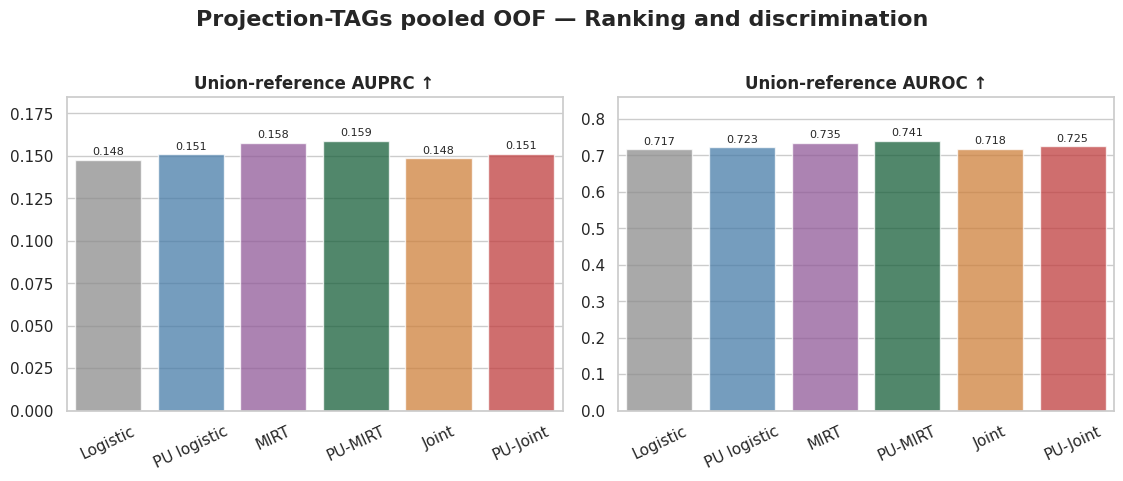

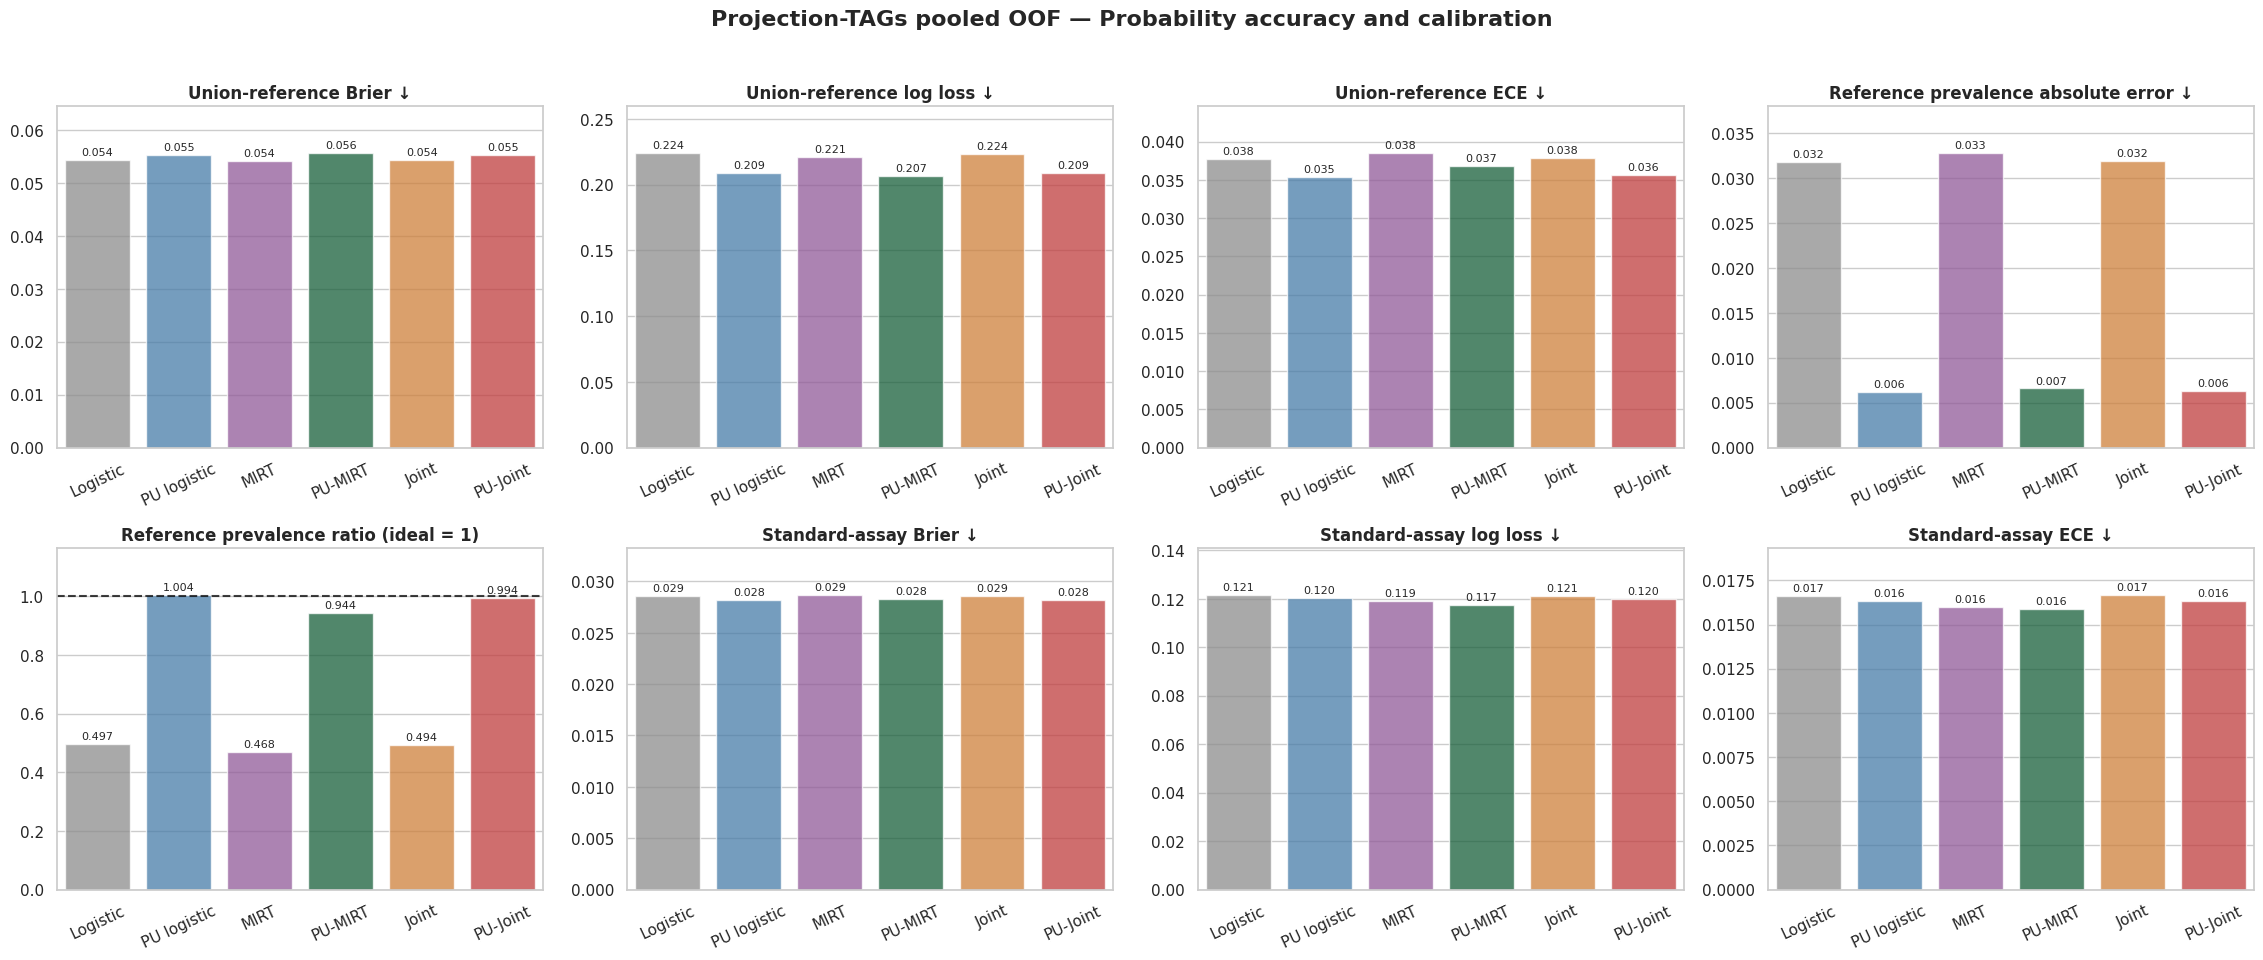

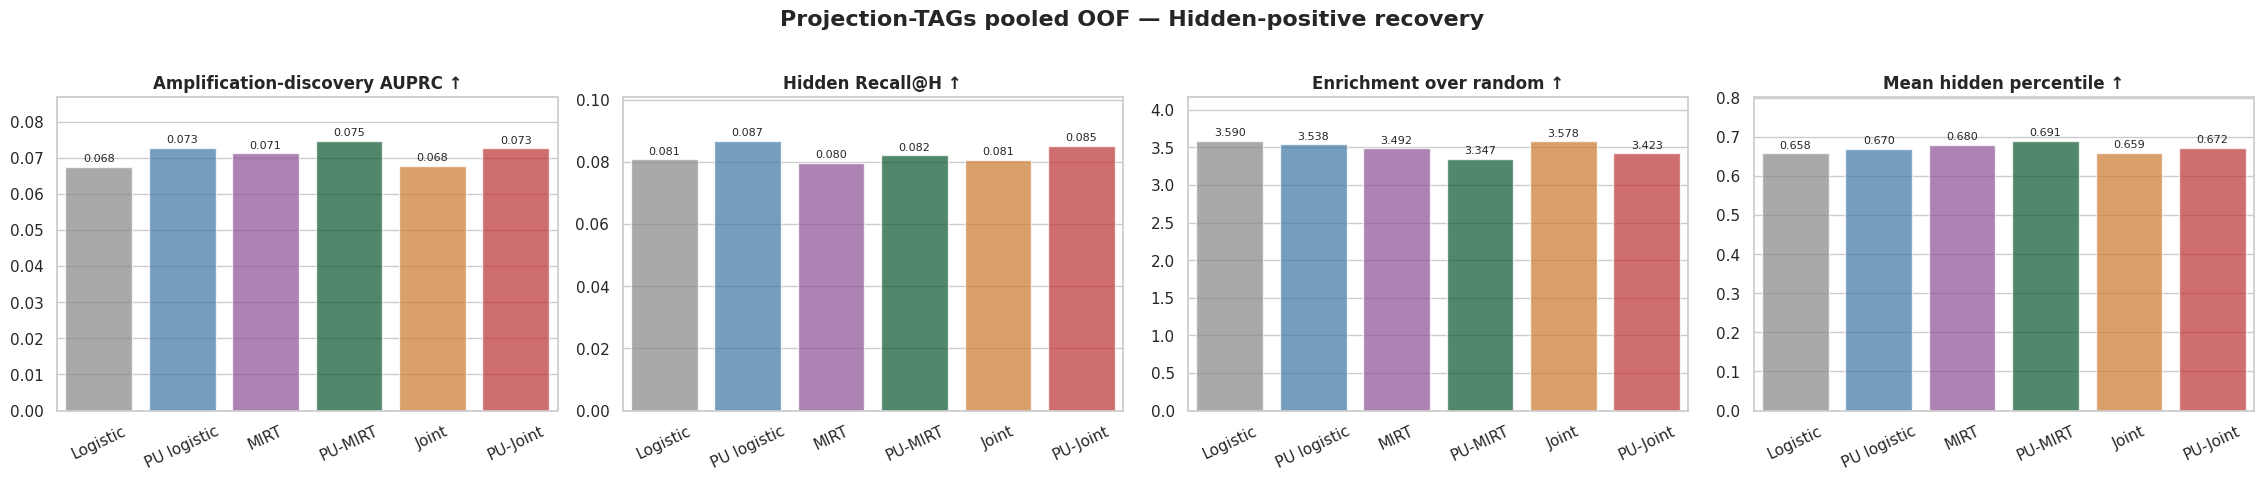

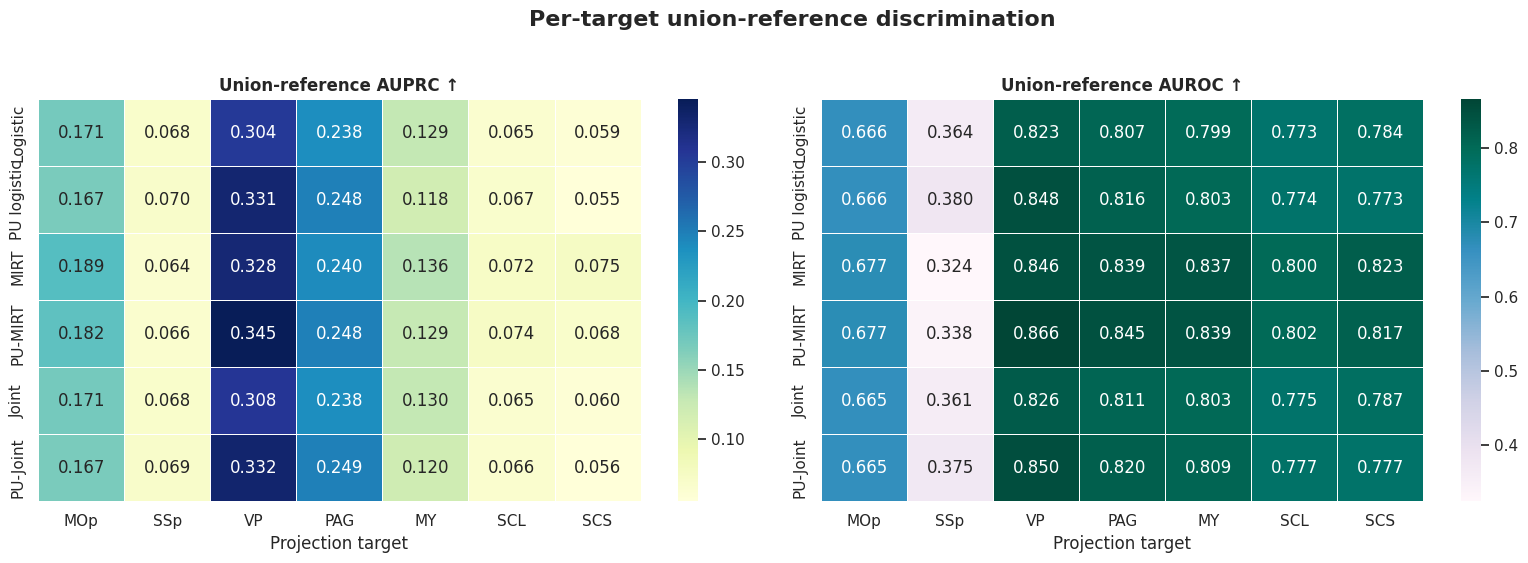

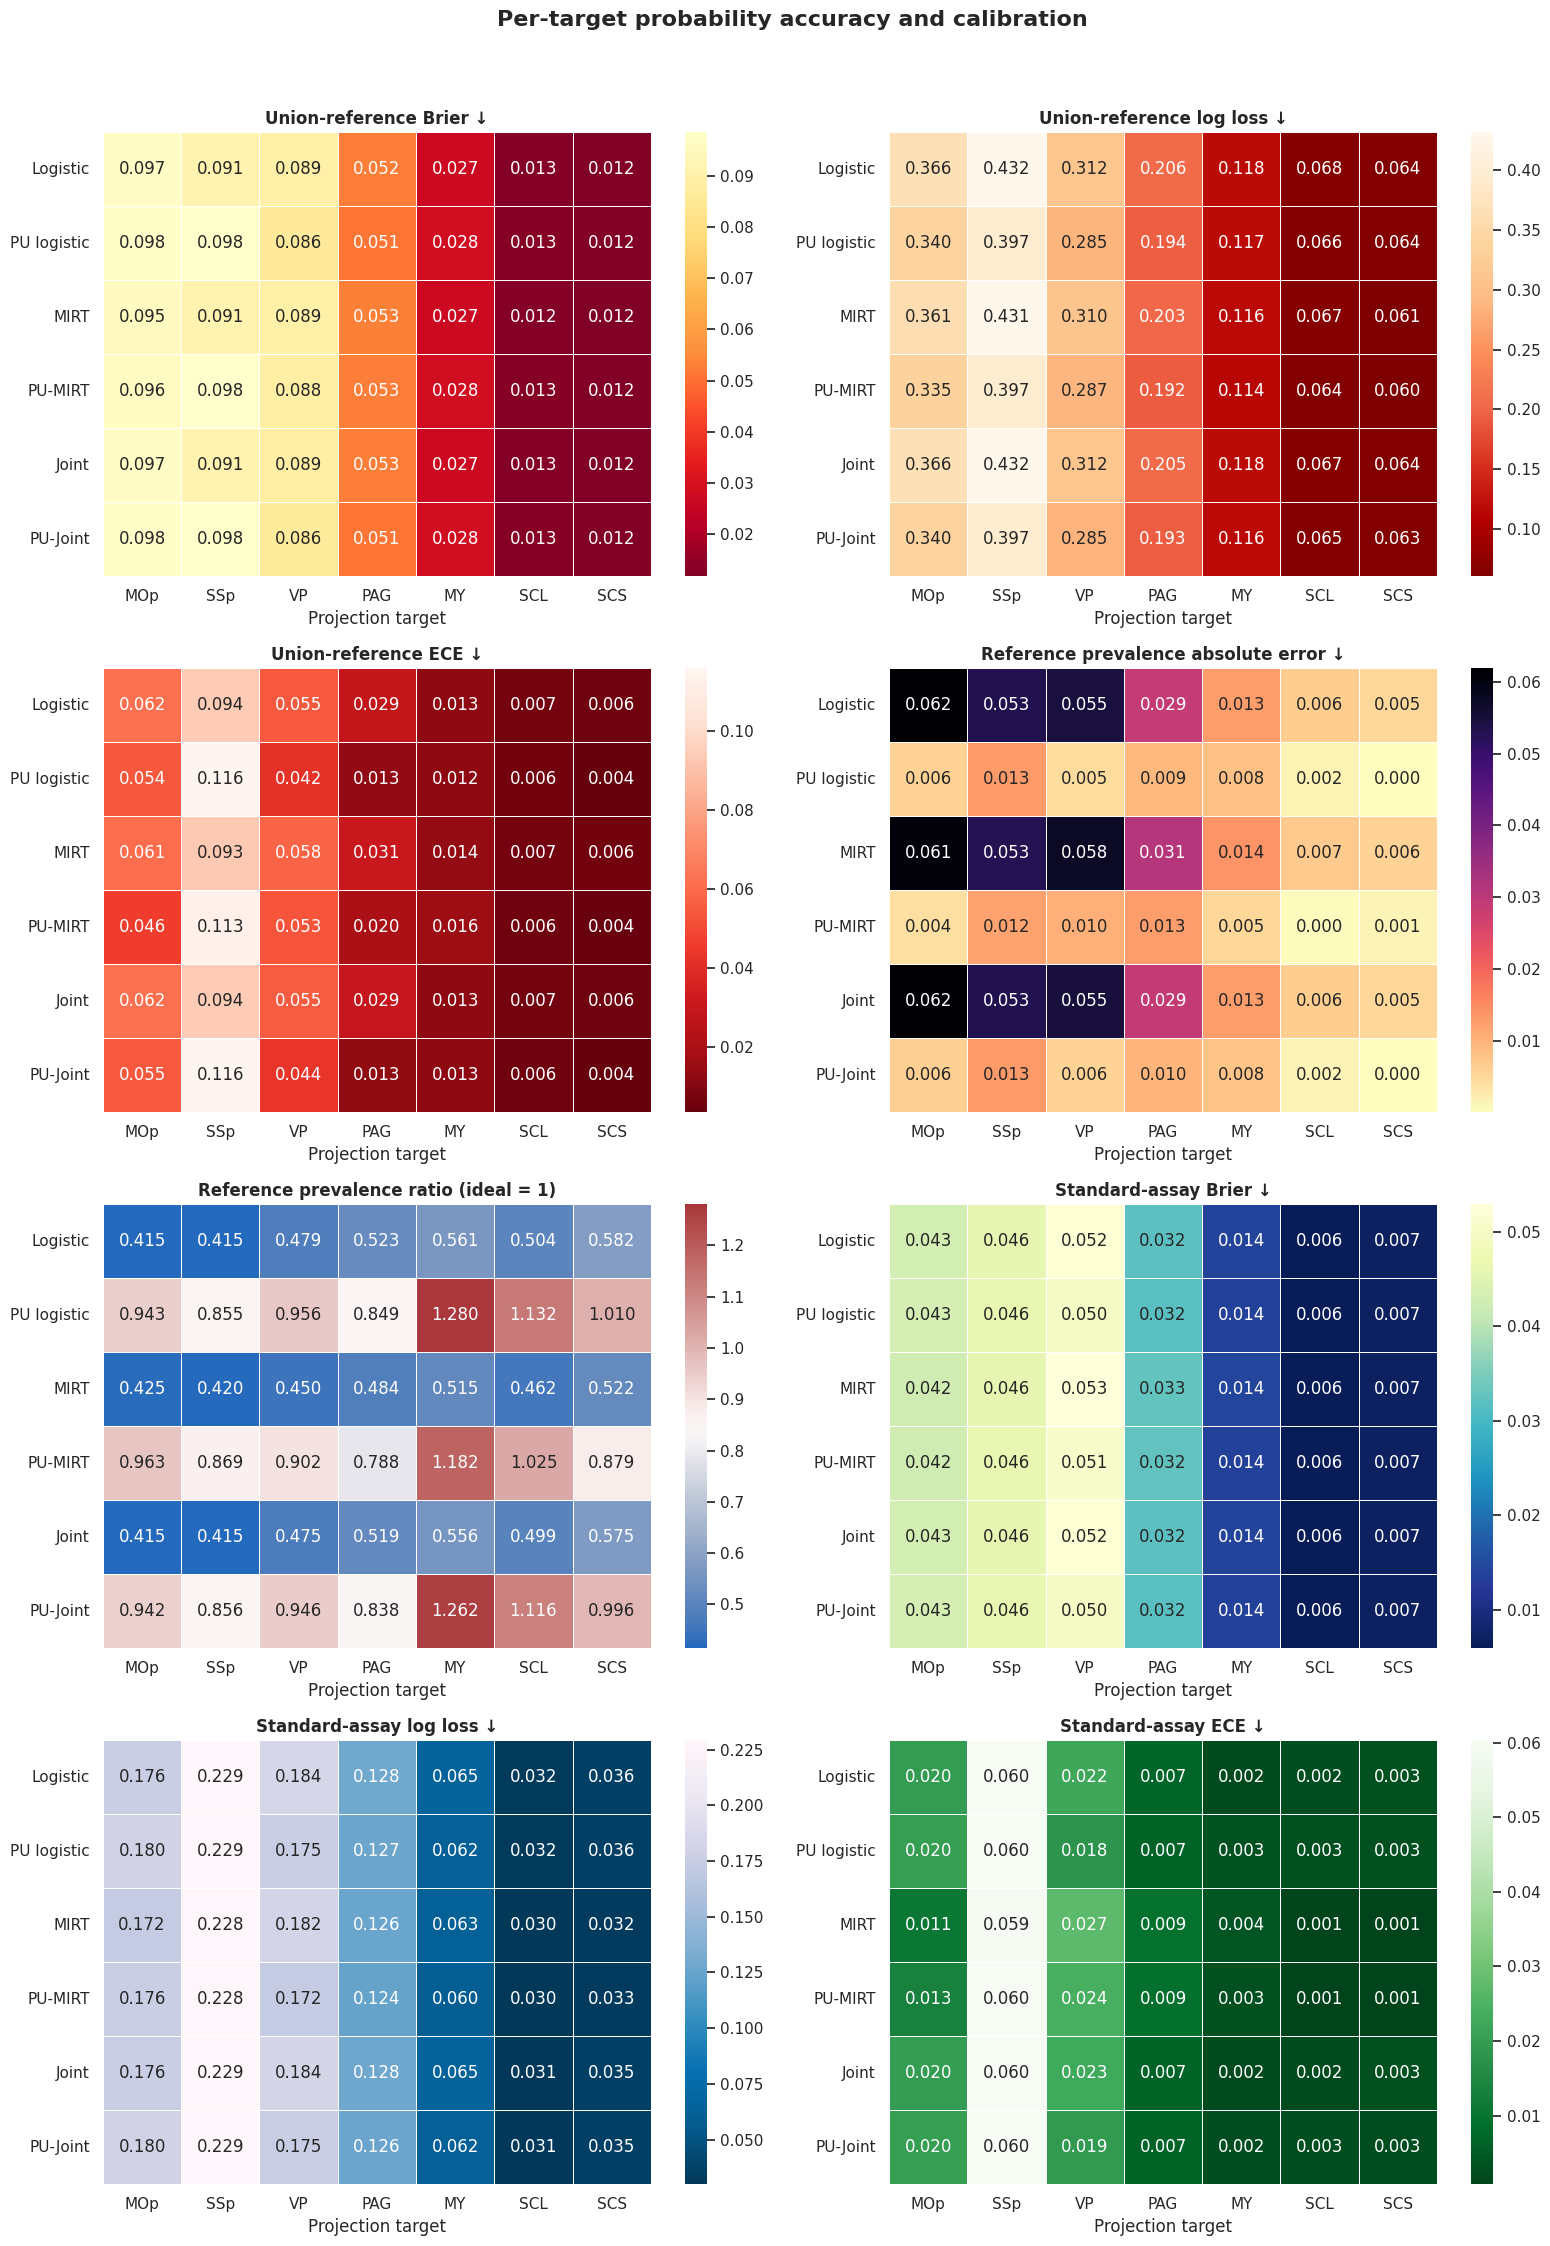

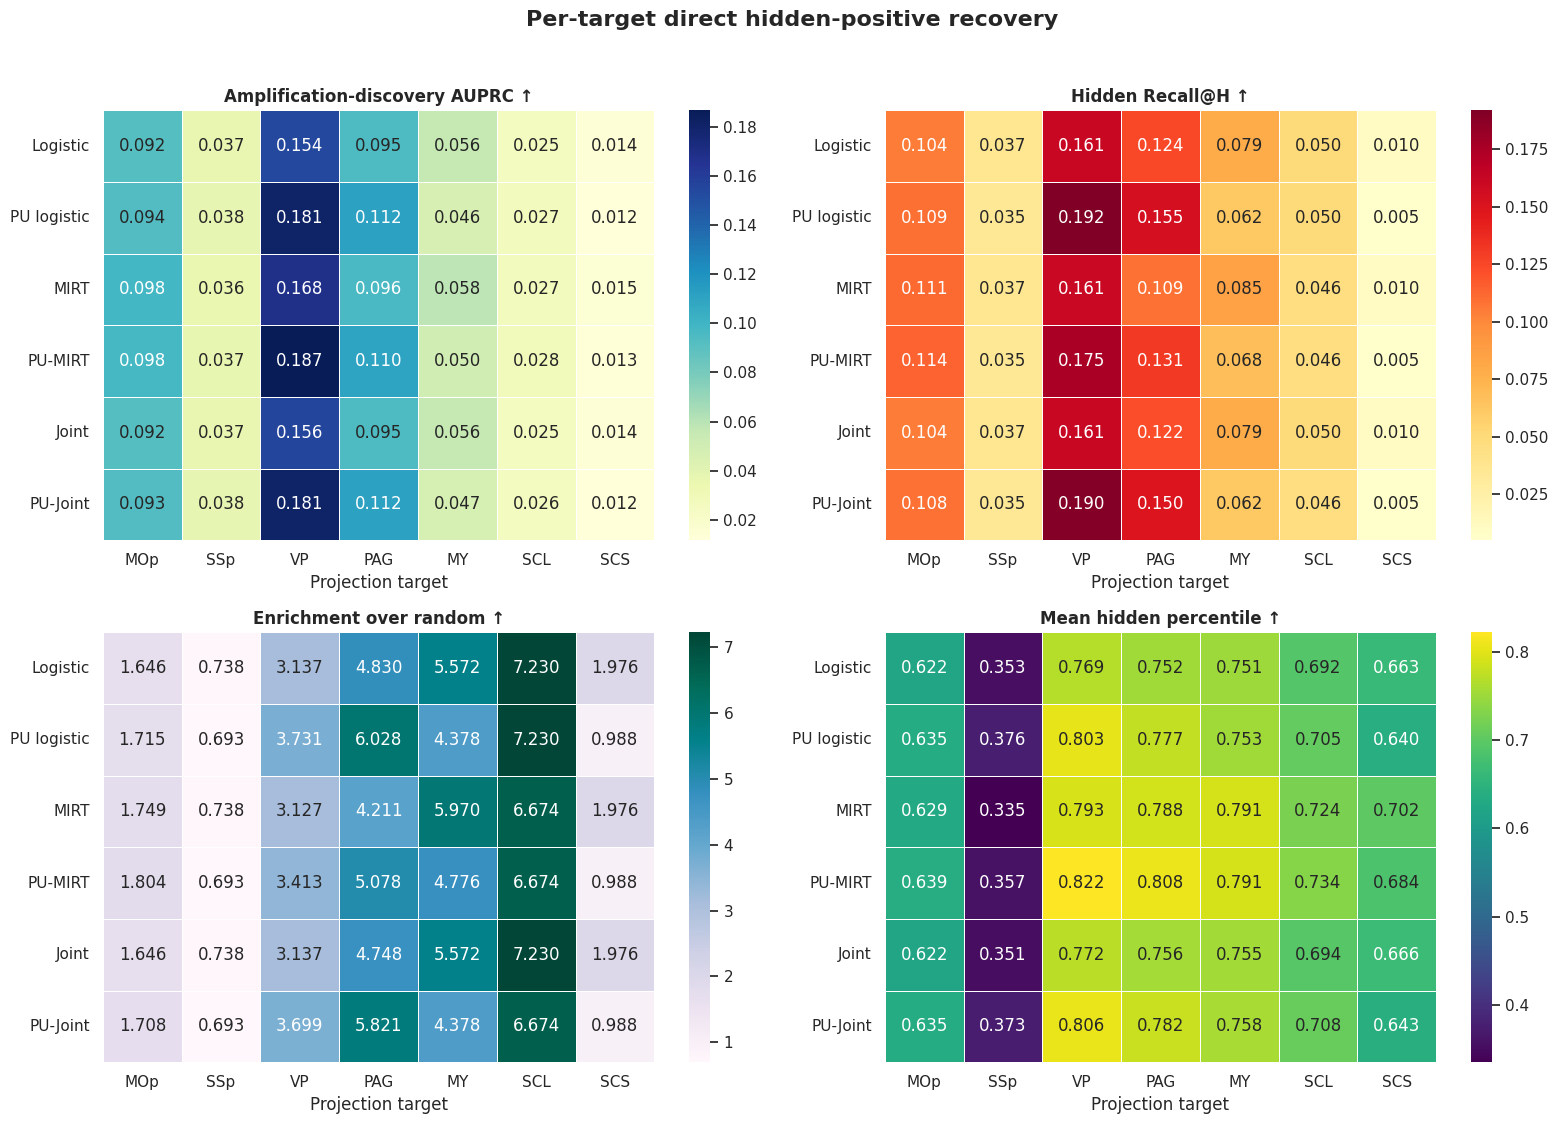

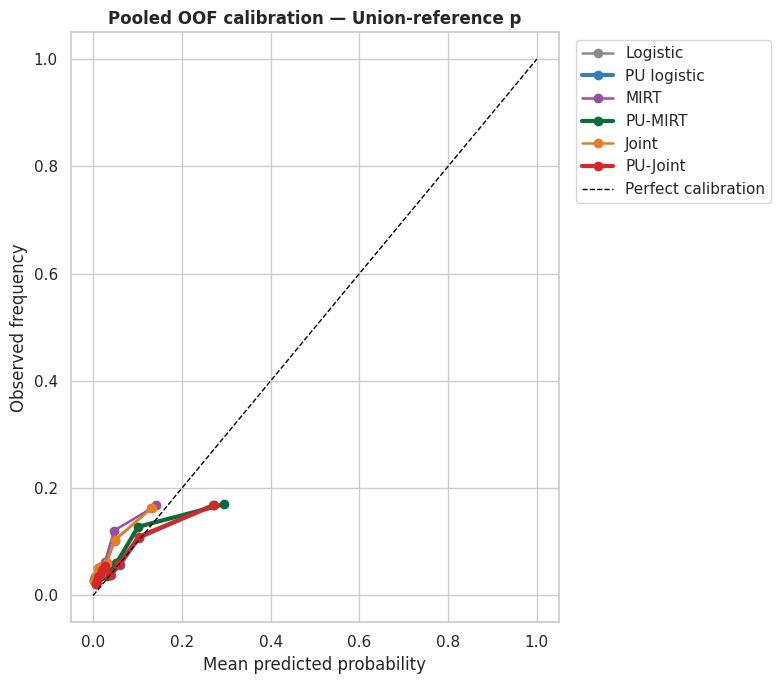

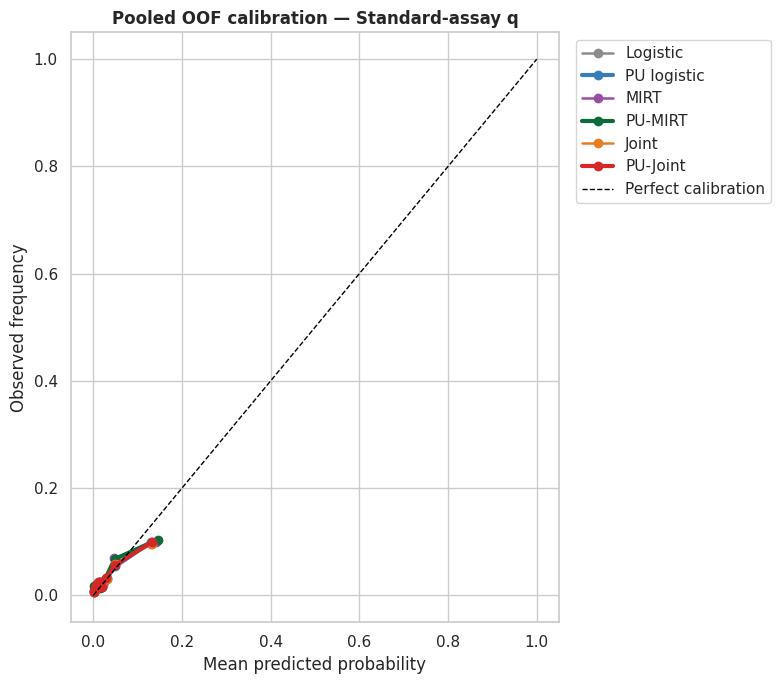

Plotted 14 pooled metrics: ['Amplification-discovery AUPRC', 'Enrichment over random', 'Hidden Recall@H', 'Mean hidden percentile', 'Reference prevalence absolute error', 'Reference prevalence ratio', 'Standard-assay Brier', 'Standard-assay ECE', 'Standard-assay log loss', 'Union-reference AUPRC', 'Union-reference AUROC', 'Union-reference Brier', 'Union-reference ECE', 'Union-reference log loss']
Saved all result figures to /content/drive/MyDrive/Gene2Wire/results/Projection_TAGs_Unified_Main/full
Final manifest updated: /content/drive/MyDrive/Gene2Wire/results/Projection_TAGs_Unified_Main/full/run_manifest.json


In [15]:
#@title Final Projection-TAGs plots — all important metrics

import math
import re

MODEL_ORDER = CORE_MODEL_NAMES

COLORS = {
    "Logistic": "#8c8c8c",
    "PU logistic": "#377eb8",
    "MIRT": "#984ea3",
    "PU-MIRT": "#0b6b3a",
    "Joint": "#e67e22",
    "PU-Joint": "#d62728",
}

# direction:
#   higher = larger is better
#   lower  = smaller is better
#   target = closest to target_value is better
METRIC_GROUPS = {
    "Ranking and discrimination": [
        ("Union-reference AUPRC", "higher", None),
        ("Union-reference AUROC", "higher", None),
    ],
    "Probability accuracy and calibration": [
        ("Union-reference Brier", "lower", None),
        ("Union-reference log loss", "lower", None),
        ("Union-reference ECE", "lower", None),
        ("Reference prevalence absolute error", "lower", None),
        ("Reference prevalence ratio", "target", 1.0),
        ("Standard-assay Brier", "lower", None),
        ("Standard-assay log loss", "lower", None),
        ("Standard-assay ECE", "lower", None),
    ],
    "Hidden-positive recovery": [
        ("Amplification-discovery AUPRC", "higher", None),
        ("Hidden Recall@H", "higher", None),
        ("Enrichment over random", "higher", None),
        ("Mean hidden percentile", "higher", None),
    ],
}


def metric_title(metric, direction, target_value=None):
    if direction == "higher":
        return f"{metric} ↑"
    if direction == "lower":
        return f"{metric} ↓"
    return f"{metric} (ideal = {target_value:g})"


def safe_filename(text):
    return re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()


def add_bar_labels(axis):
    for container in axis.containers:
        labels = [
            f"{bar.get_height():.3f}"
            if np.isfinite(bar.get_height())
            else ""
            for bar in container
        ]
        axis.bar_label(
            container,
            labels=labels,
            padding=2,
            fontsize=8,
            rotation=0,
        )


def plot_pooled_metric_group(group_name, metric_specs, figure_number):
    available_specs = [
        specification
        for specification in metric_specs
        if specification[0] in main_results.columns
    ]

    if not available_specs:
        print(f"Skipping {group_name}: no requested columns found.")
        return

    n_columns = min(4, len(available_specs))
    n_rows = math.ceil(len(available_specs) / n_columns)

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(5.7 * n_columns, 4.7 * n_rows),
        squeeze=False,
    )
    axes = axes.ravel()

    for axis, (metric, direction, target_value) in zip(
        axes, available_specs
    ):
        sns.barplot(
            data=main_results,
            x="Model",
            y=metric,
            order=MODEL_ORDER,
            hue="Model",
            hue_order=MODEL_ORDER,
            palette=COLORS,
            legend=False,
            errorbar=None,
            alpha=0.75,
            ax=axis,
        )

        axis.set_title(
            metric_title(metric, direction, target_value),
            fontweight="bold",
        )
        axis.set_xlabel("")
        axis.set_ylabel("")
        axis.tick_params(axis="x", rotation=25)
        axis.margins(y=0.16)

        if direction == "target":
            axis.axhline(
                target_value,
                linestyle="--",
                linewidth=1.5,
                color="black",
                alpha=0.75,
            )

        add_bar_labels(axis)

    for axis in axes[len(available_specs):]:
        axis.set_visible(False)

    fig.suptitle(
        f"Projection-TAGs pooled OOF — {group_name}",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()

    output_path = (
        RESULT_DIR
        / f"{figure_number:02d}_pooled_{safe_filename(group_name)}.png"
    )
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


# Plot all pooled metric groups
for figure_number, (group_name, metric_specs) in enumerate(
    METRIC_GROUPS.items(),
    start=1,
):
    plot_pooled_metric_group(
        group_name,
        metric_specs,
        figure_number,
    )


# ------------------------------------------------------------------
# Per-target heatmaps
# ------------------------------------------------------------------

def plot_per_target_heatmaps(
    dataframe,
    metric_specs,
    figure_title,
    output_filename,
    score_type=None,
):
    plot_data = dataframe.copy()

    if score_type is not None and "Score type" in plot_data.columns:
        plot_data = plot_data[
            plot_data["Score type"].eq(score_type)
        ].copy()

    available_specs = [
        specification
        for specification in metric_specs
        if specification[0] in plot_data.columns
    ]

    if not available_specs:
        print(f"Skipping {figure_title}: no requested columns found.")
        return

    n_columns = min(2, len(available_specs))
    n_rows = math.ceil(len(available_specs) / n_columns)

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(8 * n_columns, 5.5 * n_rows),
        squeeze=False,
    )
    axes = axes.ravel()

    for axis, (metric, direction, target_value, cmap) in zip(
        axes, available_specs
    ):
        heat = (
            plot_data
            .pivot(index="Model", columns="Target", values=metric)
            .reindex(index=MODEL_ORDER, columns=TARGETS)
        )

        if heat.notna().any().any():
            sns.heatmap(
                heat,
                annot=True,
                fmt=".3f",
                cmap=cmap,
                linewidths=0.4,
                linecolor="white",
                ax=axis,
            )
        else:
            axis.text(
                0.5,
                0.5,
                "No estimable values",
                ha="center",
                va="center",
                transform=axis.transAxes,
            )

        axis.set_title(
            metric_title(metric, direction, target_value),
            fontweight="bold",
        )
        axis.set_xlabel("Projection target")
        axis.set_ylabel("")

    for axis in axes[len(available_specs):]:
        axis.set_visible(False)

    fig.suptitle(
        figure_title,
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig(
        RESULT_DIR / output_filename,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


plot_per_target_heatmaps(
    discrimination_per_target,
    [
        ("Union-reference AUPRC", "higher", None, "YlGnBu"),
        ("Union-reference AUROC", "higher", None, "PuBuGn"),
    ],
    figure_title="Per-target union-reference discrimination",
    output_filename="04_per_target_union_discrimination.png",
)


plot_per_target_heatmaps(
    probability_metrics_per_target,
    [
        ("Union-reference Brier", "lower", None, "YlOrRd_r"),
        ("Union-reference log loss", "lower", None, "OrRd_r"),
        ("Union-reference ECE", "lower", None, "Reds_r"),
        (
            "Reference prevalence absolute error",
            "lower",
            None,
            "magma_r",
        ),
        (
            "Reference prevalence ratio",
            "target",
            1.0,
            "vlag",
        ),
        ("Standard-assay Brier", "lower", None, "YlGnBu_r"),
        ("Standard-assay log loss", "lower", None, "PuBu_r"),
        ("Standard-assay ECE", "lower", None, "Greens_r"),
    ],
    figure_title="Per-target probability accuracy and calibration",
    output_filename="05_per_target_probability_accuracy.png",
)


plot_per_target_heatmaps(
    hidden_recovery_per_target,
    [
        (
            "Amplification-discovery AUPRC",
            "higher",
            None,
            "YlGnBu",
        ),
        ("Hidden Recall@H", "higher", None, "YlOrRd"),
        ("Enrichment over random", "higher", None, "PuBuGn"),
        ("Mean hidden percentile", "higher", None, "viridis"),
    ],
    figure_title="Per-target direct hidden-positive recovery",
    output_filename="06_per_target_hidden_recovery.png",
    score_type="Model-specific recovery score",
)


# ------------------------------------------------------------------
# Calibration curves: plot every probability type that is available
# ------------------------------------------------------------------

for probability_name in calibration_bins["Probability"].dropna().unique():
    calibration_summary = (
        calibration_bins[
            calibration_bins["Probability"].eq(probability_name)
        ]
        .groupby(["Model", "Calibration bin"], as_index=False)[
            ["Mean predicted probability", "Observed frequency"]
        ]
        .mean()
    )

    plt.figure(figsize=(8, 7))

    for model_name in MODEL_ORDER:
        line = calibration_summary[
            calibration_summary["Model"].eq(model_name)
        ].sort_values("Calibration bin")

        if line.empty:
            continue

        plt.plot(
            line["Mean predicted probability"],
            line["Observed frequency"],
            marker="o",
            linewidth=3.0
            if model_name in {"PU logistic", "PU-MIRT", "PU-Joint"}
            else 1.8,
            color=COLORS[model_name],
            label=model_name,
        )

    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black",
        linewidth=1,
        label="Perfect calibration",
    )
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(
        f"Pooled OOF calibration — {probability_name}",
        fontweight="bold",
    )
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    output_name = (
        f"07_calibration_{safe_filename(probability_name)}.png"
    )
    plt.savefig(
        RESULT_DIR / output_name,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


# Audit which pooled metrics were plotted
requested_metrics = {
    metric
    for metric_specs in METRIC_GROUPS.values()
    for metric, _, _ in metric_specs
}
available_requested_metrics = [
    metric for metric in requested_metrics
    if metric in main_results.columns
]
missing_requested_metrics = sorted(
    requested_metrics - set(main_results.columns)
)

print(
    "Plotted",
    len(available_requested_metrics),
    "pooled metrics:",
    sorted(available_requested_metrics),
)

if missing_requested_metrics:
    print(
        "Metrics skipped because they were not present:",
        missing_requested_metrics,
    )

print("Saved all result figures to", RESULT_DIR)


run_manifest["completed_utc"] = datetime.now(timezone.utc).isoformat()
run_manifest["figure_files"] = sorted(path.name for path in RESULT_DIR.glob("*.png"))
with (RESULT_DIR / "run_manifest.json").open("w", encoding="utf-8") as handle:
    json.dump(run_manifest, handle, indent=2, sort_keys=True)
print("Final manifest updated:", RESULT_DIR / "run_manifest.json")
